## 0. Setup Inicial

In [ ]:

%%capture

import os

#Clonar o repositório do GitHub
if not os.path.exists('repositorio_grupo4/'):
  !git clone {'https://github.com/deckinhow/repositorio_grupo4.git'}
  %cd {'repositorio_grupo4/'}
else:
  %cd {'repositorio_grupo4/'}
  !git pull

#Bibliotecas que serão utilizadas
from dados_e_funcoes import funcoes #Funções criadas por nós
import statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import importlib
import yfinance as yf

#Atualizar as funções salvas no arquivo de funções
importlib.reload(funcoes)

#Remover mensagens de aviso
warnings.filterwarnings('ignore')


In [ ]:
#Conectar o Google Drive ao ambiente do notebook
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup do Banco de dados

In [ ]:
ibovespa = pd.read_csv( #aqui a tabela de acoes está "crua", vou tratar dela em seguida
    '/content/repositorio_grupo4/dados_e_funcoes/acoes.csv',
    skiprows=2, #isso vai pular as duas primeiras linhas (acoes por indice e dados de...)
    sep=';',
    encoding='latin1'
)

print(ibovespa.columns) #tratar unnameds e apagar as duas primeiras linhas, preciso pegar os tickers ('Código')

Index(['Empresa', 'Sigla', 'Código', 'Unnamed: 3'], dtype='object')


## 2. Pré processamento

In [ ]:
tck_ibovespa = ibovespa["Código"].tolist()

print(type(tck_ibovespa))
print(tck_ibovespa)

<class 'list'>
['MMMC34.SA', 'TTEN3.SA', 'ABBV34.SA', 'ABCB4.SA', 'ADBE34.SA', 'A1AP34.SA', 'A1MD34.SA', 'AERI3.SA', 'AIRB34.SA', 'A1LB34.SA', 'BABA34.SA', 'AALR3.SA', 'ALLD3.SA', 'ALOS3.SA', 'ALPA3.SA', 'ALPA4.SA', 'GOGL34.SA', 'GOGL35.SA', 'ALUP11.SA', 'AMZO34.SA', 'ABEV3.SA', 'AALL34.SA', 'AXPB34.SA', 'T1OW34.SA', 'ANIM3.SA', 'AAPL34.SA', 'A1MT34.SA', 'ARMT34.SA', 'A1NE34.SA', 'ARML3.SA', 'ASML34.SA', 'ASAI3.SA', 'A1ZN34.SA', 'ATTB34.SA', 'AURE3.SA', 'AMOB3.SA', 'AXIA3.SA', 'AXIA6.SA', 'AXIA7.SA', 'AZZA3.SA', 'B3SA3.SA', 'BIDU34.SA', 'BMGB4.SA', 'BGIP4.SA', 'BEES3.SA', 'BEES4.SA', 'BOAC34.SA', 'BRSR3.SA', 'BRSR6.SA', 'BBSE3.SA', 'BMOB3.SA', 'BERK34.SA', 'B2YN34.SA', 'B1IL34.SA', 'B2HI34.SA', 'BIED3.SA', 'BIOM3.SA', 'B1NT34.SA', 'BLAK34.SA', 'BLAU3.SA', 'X1YZ34.SA', 'SOJA3.SA', 'BKNG34.SA', 'B1PP34.SA', 'BRBI11.SA', 'BBDC3.SA', 'BBDC4.SA', 'BRAP3.SA', 'BRAP4.SA', 'SAUD3.SA', 'BBAS3.SA', 'AGRO3.SA', 'BRKM3.SA', 'BRKM5.SA', 'BRAV3.SA', 'BRST3.SA', 'B1TI34.SA', 'AVGO34.SA', 'BPAC11.SA',

In [ ]:
#azar ja vou subir a planilha do sp100 azzzzzzzzar
#user-agent falso pra impedir de ser barrado na wikipedia

import requests

url = "https://en.wikipedia.org/wiki/S%26P_100"

headers = {
    "User-Agent": "Mozilla/5.0"
}

html = requests.get(url, headers=headers).text

tab = pd.read_html(html)

print(len(tab)) #conferindo qual a tabela da página da wiki

13


In [ ]:
sp100 = tab[2]

tck_sp100 = sp100['Symbol'].tolist()

print(tck_sp100)

['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AMAT', 'AMD', 'AMGN', 'AMT', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BMY', 'BNY', 'BRK.B', 'C', 'CAT', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX', 'DE', 'DHR', 'DIS', 'DUK', 'EMR', 'FDX', 'GD', 'GE', 'GEV', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'LRCX', 'MA', 'MCD', 'MDLZ', 'MDT', 'META', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'MU', 'NEE', 'NFLX', 'NKE', 'NOW', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'PLTR', 'PM', 'QCOM', 'RTX', 'SBUX', 'SCHW', 'SO', 'SPG', 'T', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UBER', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WFC', 'WMT', 'XOM']


In [ ]:
tck_idx_sp100 = "^OEX"
tck_idx_ibov = "^BVSP"

In [ ]:
inicio = "2018-01-01"
fim = "2025-01-01"

In [ ]:
#agora é baixar os dados e (tentar) ser feliz
import yfinance as yf

tck_idx_sp100 = "^OEX"
tck_idx_ibov = "^BVSP"

inicio = "2018-01-01"
fim = "2025-01-01"

print('Baixando dados do S&P100...')
dados_sp100 = yf.download(tck_sp100, start=inicio, end=fim,
                          auto_adjust=True, progress=False)['Close']
indice_sp100 = yf.download(tck_idx_sp100, start=inicio, end=fim,
                          auto_adjust=True, progress=False)['Close']

print('Baixando dados do IBOVESPA...')
dados_ibov = yf.download(tck_ibovespa, start=inicio, end=fim,
                          auto_adjust=True, progress=False)['Close']
indice_ibov = yf.download(tck_idx_ibov, start=inicio, end=fim,
                          auto_adjust=True, progress=False)['Close']

#já deu pra ver que deu erro em 15 downloads... tratamento de dados vai ter que vir em peso.

Baixando dados do S&P100...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


Baixando dados do IBOVESPA...


ERROR:yfinance:
15 Failed downloads:
ERROR:yfinance:['U2PS34.SA', 'CCTY3.SA', 'AUAU3.SA', 'S2ED34.SA', 'EMBJ3.SA', 'MOTV3.SA', 'AXIA7.SA', 'CYRE4.SA', 'C2OL34.SA', 'P2AN34.SA', 'STOC34.SA', 'RENT4.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1514772000, endDate = 1735700400")')
ERROR:yfinance:['RZAT11.SA', 'BRST3.SA', 'M2ST34.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01)')


In [ ]:
print(dados_ibov) #só um pequeno teste
print(indice_ibov) #outro pequeno little minusculo teste

Ticker      A1AP34.SA  A1LB34.SA  A1MD34.SA   A1MT34.SA   A1NE34.SA  \
Date                                                                  
2018-01-02        NaN        NaN        NaN         NaN         NaN   
2018-01-03        NaN        NaN        NaN         NaN         NaN   
2018-01-04        NaN        NaN        NaN         NaN         NaN   
2018-01-05        NaN        NaN        NaN         NaN         NaN   
2018-01-08        NaN        NaN        NaN         NaN         NaN   
...               ...        ...        ...         ...         ...   
2024-12-20  16.015421  22.347282  91.589996   99.127403  170.509995   
2024-12-23  16.445627  22.603239  97.000000  103.092506  174.759995   
2024-12-26  16.797615  22.583551  97.489998  103.092506  176.690002   
2024-12-27  16.729172  22.386656  96.500000  101.972366  174.410004   
2024-12-30  17.403816  21.717224  95.150002  100.396240  172.800003   

Ticker       A1ZN34.SA   AALL34.SA   AALR3.SA  AAPL34.SA  ABBV34.SA  ...  \


In [ ]:
import os

# Define the directory path
save_directory = '/content/drive/MyDrive/Colab'

# Create the directory if it does not exist
os.makedirs(save_directory, exist_ok=True)

# salvando ne bbs (no drive, posso baixar dps)

dados_sp100.to_csv(f'{save_directory}/sp100_precos.csv')
dados_ibov.to_csv(f'{save_directory}/ibov_precos.csv')
indice_sp100.to_csv(f'{save_directory}/sp100_indice.csv')
indice_ibov.to_csv(f'{save_directory}/ibov_indice.csv')

In [ ]:
print(f'\n✅ S&P100: {dados_sp100.shape[1]} ações × {dados_sp100.shape[0]} pregões') #x ações e y pregões da sp100
print(f'✅ IBOVESPA: {dados_ibov.shape[1]} ações × {dados_ibov.shape[0]} pregões') #A ações e B pregões do ibov

print(f'\nPeríodo S&P100: {dados_sp100.index[0].date()} → {dados_sp100.index[-1].date()}') #aqui printa o período. parece que deu tudo certo. do começo de 2018 ate o começo de 2025 (final de 24) tem 7 anos!
print(f'Período IBOVESPA: {dados_ibov.index[0].date()} → {dados_ibov.index[-1].date()}')

print('\nPrimeiras linhas do S&P100:') #autoexplicativo
print(dados_sp100.head(3))

print('\nPrimeiras linhas do IBOVESPA:') #autoexplicativo
print(dados_ibov.head(3))

print('\nPrimeiras linhas do índice S&P100:') #autoexplicativo
print(indice_sp100.head(3))

print('\nPrimeiras linhas do índice IBOVESPA:') #autoexplicativo
print(indice_ibov.head(3))


✅ S&P100: 101 ações × 1761 pregões
✅ IBOVESPA: 490 ações × 1738 pregões

Período S&P100: 2018-01-02 → 2024-12-31
Período IBOVESPA: 2018-01-02 → 2024-12-30

Primeiras linhas do S&P100:
Ticker           AAPL       ABBV        ABT         ACN        ADBE  \
Date                                                                  
2018-01-02  40.267071  68.773155  50.506092  135.558243  177.699997   
2018-01-03  40.260067  69.849350  50.617756  136.183899  181.039993   
2018-01-04  40.447071  69.451042  50.531849  137.796417  183.220001   

Ticker           AMAT    AMD        AMGN         AMT       AMZN  ...  UBER  \
Date                                                             ...         
2018-01-02  48.314194  10.98  136.742599  113.834457  59.450500  ...   NaN   
2018-01-03  49.170448  11.55  139.322906  114.278053  60.209999  ...   NaN   
2018-01-04  49.452827  12.12  138.735779  112.608414  60.479500  ...   NaN   

Ticker             UNH         UNP        UPS        USB           V

In [ ]:
#calculando os retornos, em especial o logaritmico.

ret_sp100 = np.log(dados_sp100 / dados_sp100.shift(1))
ret_ibov = np.log(dados_ibov / dados_ibov.shift(1))

ret_sp100 = ret_sp100.dropna(how='all') #how='all' mantém linhas úteis (sem isso, perderíamos muitos dados valiosos!)
ret_ibov = ret_ibov.dropna(how='all')

ret_idx_sp = np.log(indice_sp100 / indice_sp100.shift(1)).dropna()
ret_idx_ib = np.log(indice_ibov / indice_ibov.shift(1)).dropna()

print('Formato dos retornos S&P100:', ret_sp100.shape)
print('Formato dos retornos IBOV: ', ret_ibov.shape)
print(f'\nRetorno médio diário do S&P100: {ret_idx_sp.mean().iloc[0]:.4%}') #mudei o método, pois mean() retorna uma séri. :.4% precisa de um float!, então
                                                                            #usei o .iloc[0] para extrair um valor numérico
print(f'Retorno médio diário do IBOV: {ret_idx_ib.mean().iloc[0]:.4%}')

print(f'\nVolatilidade diária S&P100: {ret_idx_sp.std().iloc[0]:.4%}')
print(f'Volatilidade diária IBOV: {ret_idx_ib.std().iloc[0]:.4%}')

Formato dos retornos S&P100: (1760, 101)
Formato dos retornos IBOV:  (1737, 490)

Retorno médio diário do S&P100: 0.0503%
Retorno médio diário do IBOV: 0.0250%

Volatilidade diária S&P100: 1.2692%
Volatilidade diária IBOV: 1.5464%


In [ ]:
#salvando ne bbs mais uma vez (no drive, posso baixar dps)

ret_sp100.to_csv('/content/drive/MyDrive/Colab/sp100_retornos.csv')
ret_ibov.to_csv('/content/drive/MyDrive/Colab/ibov_ret.csv')

In [ ]:
#! git checkout develop

######**Identidade Visual**

In [ ]:
def estilo_finor():
    c_fundo         = '#2D2D2D'
    c_fundo_alt     = '#383838'
    c_grid          = '#3A3A3A'
    c_eixos         = '#4A4A4A'
    c_texto_sec     = '#E0E0E0'
    c_legendas      = '#B8B8B8'
    c_laranja_finor = '#FF6B35'
    paleta_finor    = ['#FF6B35', '#4A90E2', '#00D084', '#FF8C42', '#00FF41', '#B8B8B8']

    mpl.rcParams.update({
        # Figura
        'figure.facecolor':    c_fundo,
        'figure.figsize':      (10, 5),
        'figure.dpi':          120,
        # Eixos
        'axes.facecolor':      c_fundo,
        'savefig.facecolor':   c_fundo,
        'axes.edgecolor':      c_eixos,
        'axes.linewidth':      1.0,
        'axes.labelcolor':     c_texto_sec,
        'axes.labelsize':      11,
        'axes.labelpad':       6,
        # Título
        'axes.titlesize':      16,
        'axes.titlecolor':     c_laranja_finor,
        'axes.titlelocation':  'left',
        'axes.titlepad':       10,
        'axes.titleweight':    'bold',
        # Fonte
        'font.family':         'sans-serif',
        'font.sans-serif':     ['Arial', 'DejaVu Sans'],
        'text.color':          c_texto_sec,
        # Grid
        'axes.grid':           True,
        'grid.color':          c_grid,
        'grid.linestyle':      '--',
        'grid.linewidth':      0.6,
        'grid.alpha':          0.7,
        # Ticks
        'xtick.color':         c_legendas,
        'ytick.color':         c_legendas,
        'xtick.labelsize':     10,
        'ytick.labelsize':     10,
        'xtick.major.pad':     4,
        'ytick.major.pad':     4,
        'xtick.major.size':    4,
        'ytick.major.size':    4,
        # Legenda
        'legend.facecolor':    c_fundo_alt,
        'legend.edgecolor':    c_eixos,
        'legend.fontsize':     10,
        'legend.labelcolor':   c_texto_sec,
        'legend.frameon':      True,
        'legend.borderpad':    0.6,
        'legend.handlelength': 1.5,

        # Linhas e patches
        'lines.linewidth':     2.0,
        'patch.linewidth':     0.5,
        'patch.edgecolor':     c_eixos,

        # Exportação
        'savefig.facecolor':   c_fundo,
        'savefig.dpi':         150,
        'savefig.bbox':        'tight',
        'savefig.pad_inches':  0.2,

        # Ciclo de cores
        'axes.prop_cycle':     mpl.cycler(color=paleta_finor),
    })

    plt.rcParams['axes.spines.top']   = False
    plt.rcParams['axes.spines.right'] = False

    sns.set_palette(sns.color_palette(paleta_finor))

estilo_finor()

## 3.Análise Exploratória de Dados

In [ ]:
! pip install missingno

####3.1 Qualidade de Dados

3.1.1 Análise de Dados Faltantes

Dados nulos | S&P100
Total de ações: 101
Ações completas: 97
Ações nulos: 4

Ações com mais de 5% de dados faltantes:
Ticker
BRK.B    100.00
GEV       89.04
PLTR      39.24
UBER      19.31
dtype: float64
Dados nulos | IBOV
Total de ações: 490
Ações completas: 240
Ações nulos: 250

Ações com mais de 5% de dados faltantes:
Ticker
AUAU3.SA     100.00
C2OL34.SA    100.00
BRST3.SA     100.00
AXIA7.SA     100.00
CYRE4.SA     100.00
              ...  
TGAR11.SA     10.82
RBRP11.SA      8.92
KNHY11.SA      8.75
VGIR11.SA      8.29
HGRU11.SA      8.23
Length: 244, dtype: float64


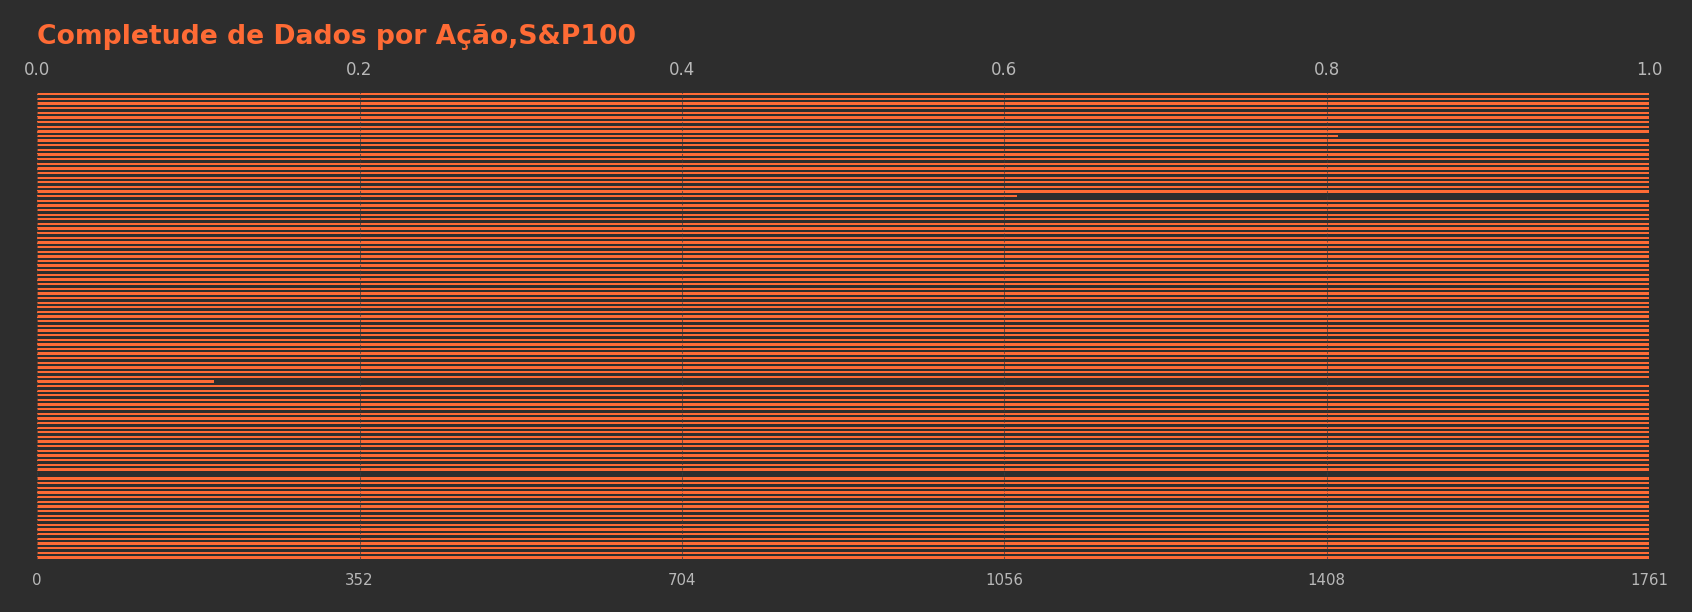

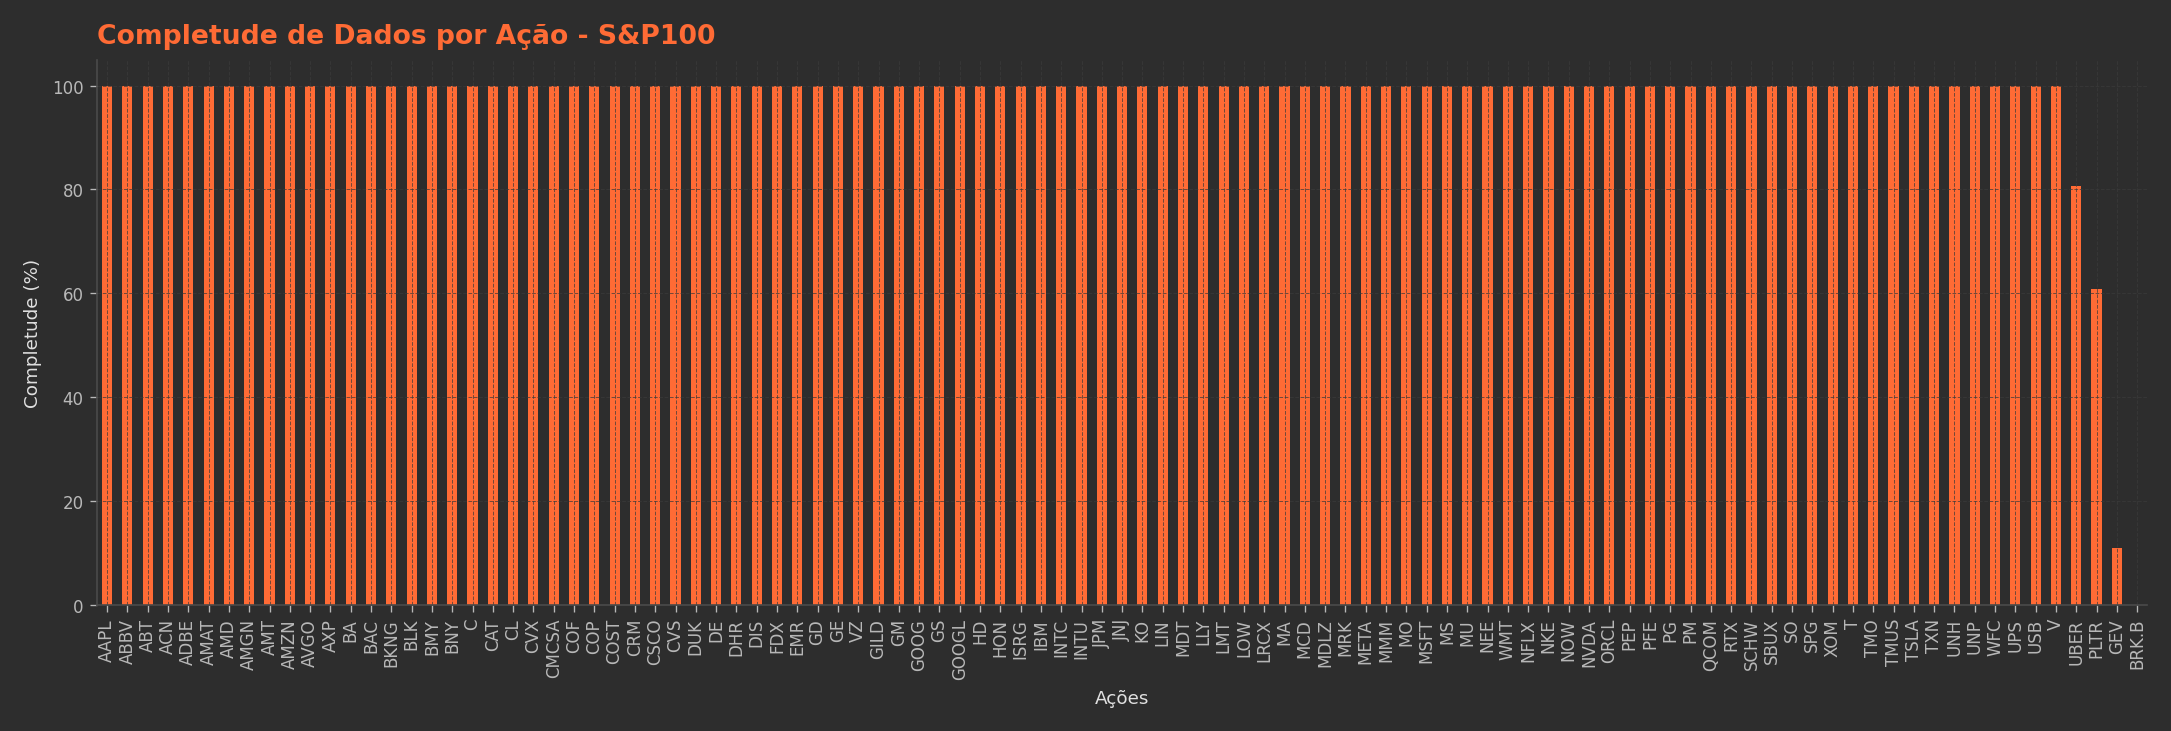

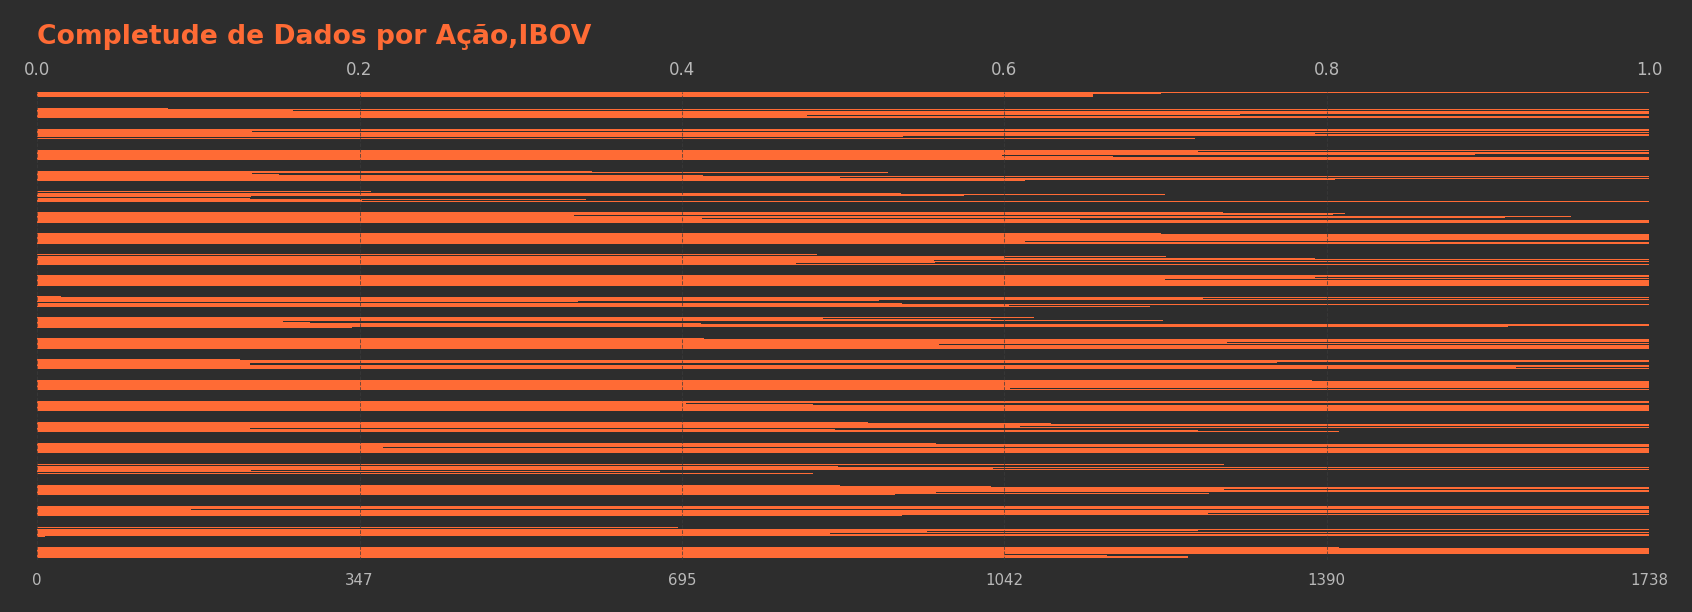

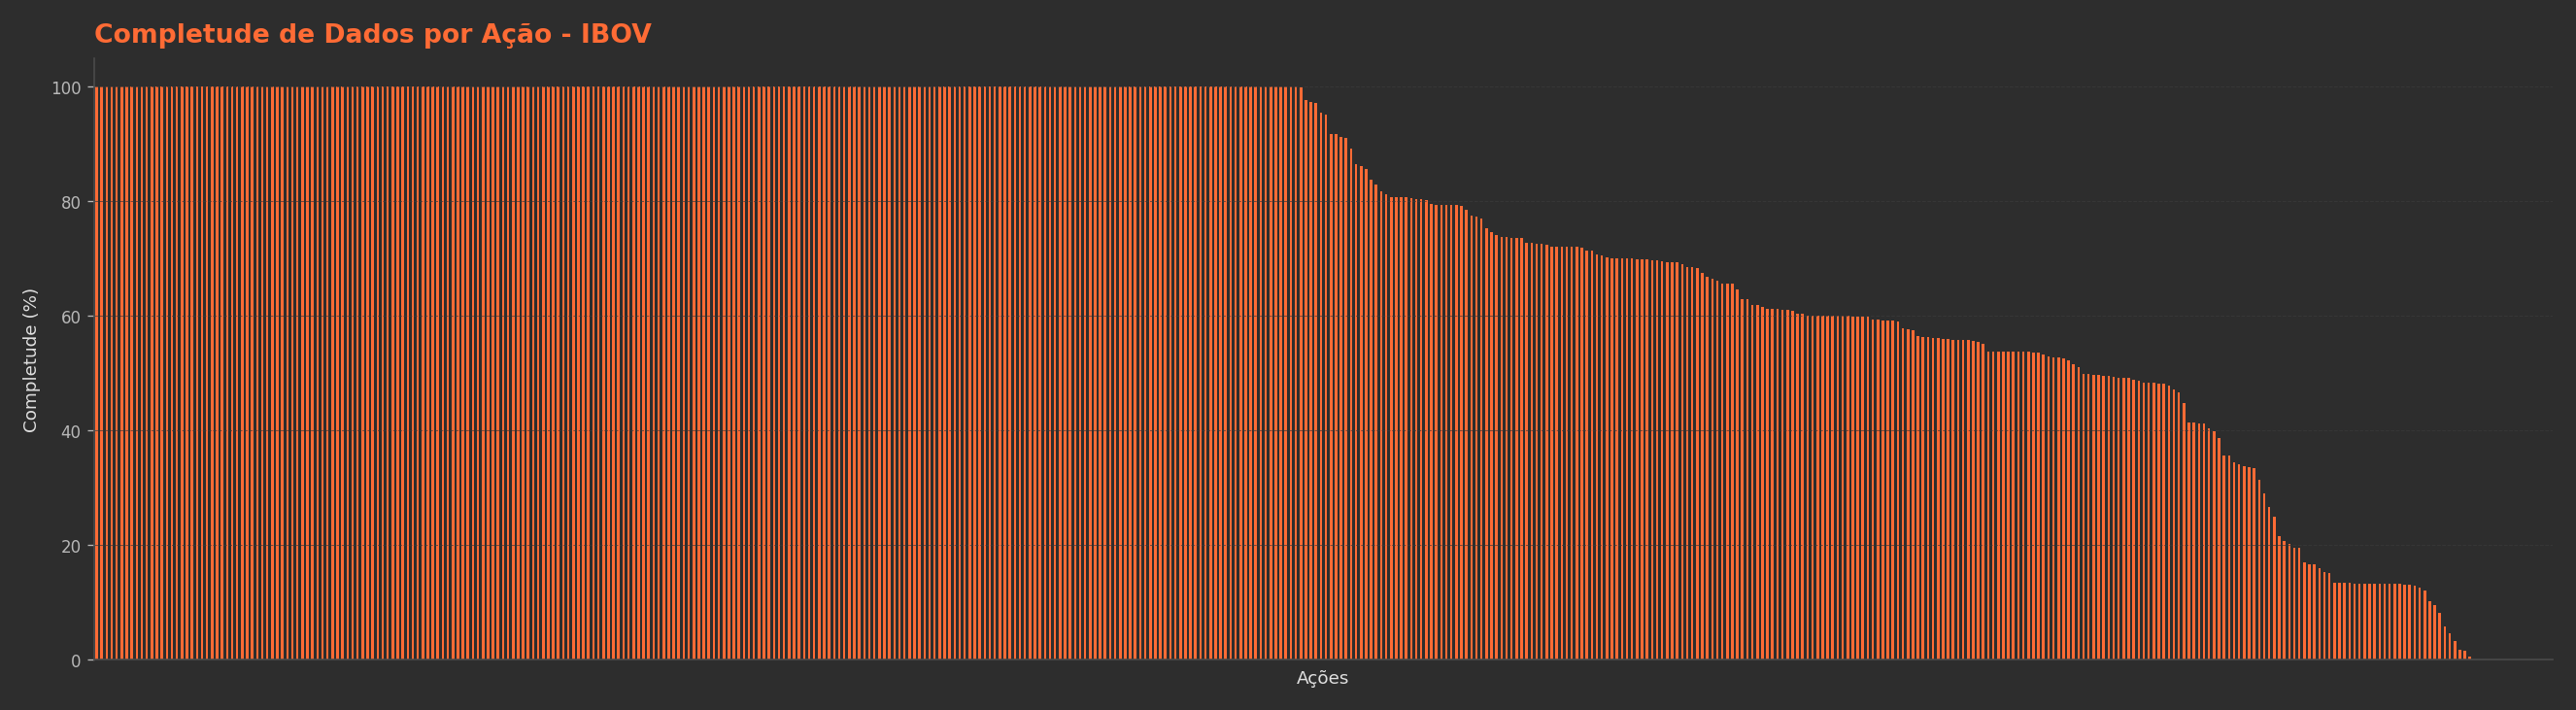

In [ ]:
#3.0.0 importando as bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns


# 3.1.0 Contagem e percentual de nulos por ação

  # 3.1.1 Conta nulos
nulos_sp = dados_sp100.isnull().sum()
nulos_ib = dados_ibov.isnull().sum()

  # 3.1.2 Percentual de nulos
pct_nulos = (nulos_sp / len(dados_sp100) * 100).round(2) #SP
pct_ib = (nulos_ib / len(dados_ibov) * 100).round(2) #IBOV

  #3.1.3 Imprime os dados
print('Dados nulos | S&P100')
print(f'Total de ações: {dados_sp100.shape[1]}')
print(f'Ações completas: {(pct_nulos == 0).sum()}')
print(f'Ações nulos: {(pct_nulos > 0).sum()}')
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

print('===================================================')
print('Dados nulos | IBOV')
print(f'Total de ações: {dados_ibov.shape[1]}')
print(f'Ações completas: {(pct_ib == 0).sum()}')
print(f'Ações nulos: {(pct_ib > 0).sum()}')
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_ib[pct_ib > 5].sort_values(ascending=False))

#EXEMPLO DOCUMENTO SP 100
# Visualização,mapa de calor de dados faltantes
# (usando missingno,pip install missingno)
import missingno as msno
fig, ax = plt.subplots(figsize=(14, 5))
msno.bar(dados_sp100, ax=ax, color='#FF6B35', fontsize=9)
for eixo in fig.axes:
    eixo.get_yaxis().set_visible(False)
ax.set_title('Completude de Dados por Ação,S&P100', fontweight='bold')
plt.tight_layout()
plt.savefig('missing_sp100.png', dpi=150)
plt.show()


#EXEMPLO LEGÍVEL SP 100
import matplotlib.pyplot as plt

# calcula percentual de completude
completude = dados_sp100.notnull().mean() * 100

# remove Date se existir
completude = completude.drop('Date', errors='ignore')

# ORDENA do maior para o menor
completude = completude.sort_values(ascending=False)

# gráfico
plt.figure(figsize=(18,6))

completude.plot(kind='bar', color='#FF6B35', edgecolor='none')
plt.title('Completude de Dados por Ação - S&P100')

plt.xlabel('Ações')
plt.ylabel('Completude (%)')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

#EXEMPLO DOCUMENTO IBOV
# Visualização,mapa de calor de dados faltantes
# (usando missingno,pip install missingno)
import missingno as msno
fig, ax = plt.subplots(figsize=(14, 5))
msno.bar(dados_ibov, ax=ax, color='#FF6B35', fontsize=9)
for eixo in fig.axes:
    eixo.get_yaxis().set_visible(False)
ax.set_title('Completude de Dados por Ação,IBOV', fontweight='bold')
plt.tight_layout()
plt.savefig('missing_ibov.png', dpi=150)
plt.show()

#EXEMPLO LEGÍVEL IBOV
import matplotlib.pyplot as plt

# calcula percentual de completude
completude = dados_ibov.notnull().mean() * 100

# remove Date se existir
completude = completude.drop('Date', errors='ignore')

# ORDENA do maior para o menor
completude = completude.sort_values(ascending=False)

# gráfico
plt.figure(figsize=(22,6))

completude.plot(kind='bar', color='#FF6B35')

plt.title('Completude de Dados por Ação - IBOV')

plt.xlabel('Ações')
plt.ylabel('Completude (%)')
# esconde labels
plt.xticks([])

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()








In [ ]:
dados_sp100.head()

Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMAT,AMD,AMGN,AMT,AMZN,...,UBER,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267071,68.773155,50.506092,135.558243,177.699997,48.314194,10.98,136.742599,113.834457,59.450500,...,NaN,193.090439,113.271820,88.351791,39.016354,107.888237,33.712959,48.376751,28.800230,58.185505
2018-01-03,40.260067,69.849350,50.617756,136.183899,181.039993,49.170448,11.55,139.322906,114.278053,60.209999,...,NaN,195.115982,113.905823,90.309273,39.399075,108.962318,33.020184,48.748936,29.051462,59.328262
2018-01-04,40.447071,69.451042,50.531849,137.796417,183.220001,49.452827,12.12,138.735779,112.608414,60.479500,...,NaN,195.962860,113.288506,90.895081,39.702374,109.367477,33.127239,49.358696,29.077751,59.410389
2018-01-05,40.907566,70.660034,50.677887,138.933060,185.339996,49.735203,11.88,139.562408,113.334343,61.457001,...,NaN,199.699692,114.731773,91.173714,39.947887,111.986710,33.051670,49.691284,29.250101,59.362469
2018-01-08,40.755630,69.527870,50.531849,140.043335,185.039993,50.937588,12.28,139.523834,114.544250,62.343498,...,NaN,196.233551,116.325119,92.281059,40.005661,112.438950,32.994991,49.129044,29.682446,59.629375


3.1.2 Como Tratar os Dados Faltantes

In [ ]:
# Estratégia de tratamento de missing values

# 3.1.1 Conta nulos
nulos_sp = dados_sp100.isnull().sum()
nulos_ib = dados_ibov.isnull().sum()

# 3.1.2 Percentual de nulos
pct_nulos = (nulos_sp / len(dados_sp100) * 100).round(2) #SP
pct_ib = (nulos_ib / len(dados_ibov) * 100).round(2) #IBOV

# Passo 1: Remover ações com mais de 20% de dados faltantes
limite_remocao = 20
acoes_validas_sp = pct_nulos[pct_nulos <= limite_remocao].index
acoes_validas_ib = pct_ib[pct_ib <= limite_remocao].index
dados_sp100_clean = dados_sp100[acoes_validas_sp].copy()
dados_ibov_clean = dados_ibov[acoes_validas_ib].copy()
print(f'S&P100: {dados_sp100.shape[1]} → {dados_sp100_clean.shape[1]} ações válidas')
print(f'IBOV: {dados_ibov.shape[1]} → {dados_ibov_clean.shape[1]} ações válidas')
# Passo 2: Preencher dados faltantes restantes com forward fill
dados_sp100_clean = dados_sp100_clean.ffill()
dados_ibov_clean = dados_ibov_clean.ffill()
# Passo 3: Verificar se ainda há nulos (linhas iniciais podem ter NaN)
dados_sp100_clean = dados_sp100_clean.dropna(how='all')
dados_ibov_clean = dados_ibov_clean.dropna(how='all')
# Recalcular retornos com dados limpos
ret_sp100_clean = np.log(dados_sp100_clean / dados_sp100_clean.shift(1)).dropna()
ret_ibov_clean = np.log(dados_ibov_clean / dados_ibov_clean.shift(1)).dropna()
print(f'\nRetornos finais,S&P100: {ret_sp100_clean.shape}')
print(f'Retornos finais,IBOV: {ret_ibov_clean.shape}')

S&P100: 101 → 98 ações válidas
IBOV: 490 → 266 ações válidas

Retornos finais,S&P100: (1420, 98)
Retornos finais,IBOV: (1392, 266)


3.1.3 Identificação de Outliers nos Retornos

Ações com retornos diários > 15% (S&P100):
Ticker
TSLA    10
BA       8
META     6
SPG      6
C        4
COF      4
INTC     4
LRCX     4
NVDA     4
MS       4
GM       4
BAC      4
AXP      4
UBER     4
CVX      4
dtype: int64

Dias com retorno extremo,TSLA:
Date
2020-09-08   -0.236518
2020-03-16   -0.205522
2024-10-24    0.198187
2020-02-05   -0.188450
2020-02-03    0.181445
2021-03-09    0.179327
2020-03-18   -0.174763
2020-03-19    0.168795
2019-10-24    0.162707
2020-03-24    0.150846
Name: TSLA, dtype: float64


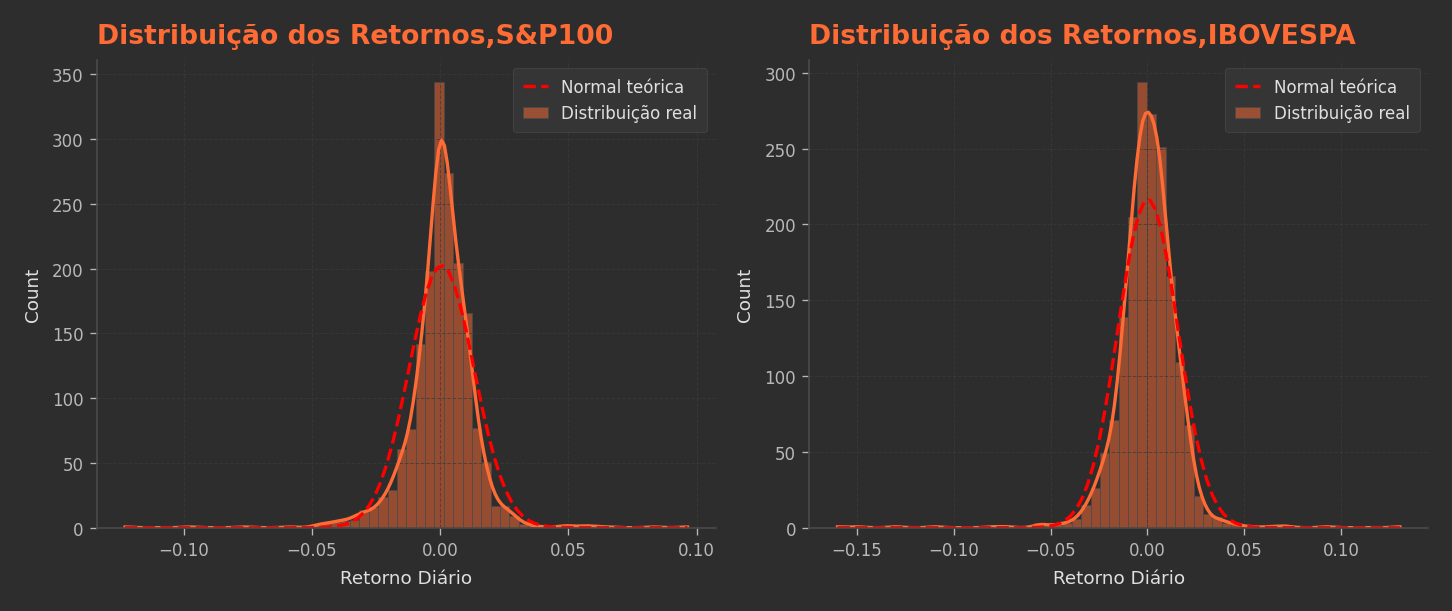


Curtose S&P100: 12.42 (normal = 0)
Curtose IBOV: 20.18 (normal = 0)
Valores positivos = caudas gordas (fat tails),comum em finanças


In [ ]:
from scipy import stats
# Detectar retornos extremos por ação
limite_outlier = 0.15 # ±15% em um dia,ajuste conforme necessário
outliers_sp = (ret_sp100_clean.abs() > limite_outlier).sum()
print('Ações com retornos diários > 15% (S&P100):')
print(outliers_sp[outliers_sp > 0].sort_values(ascending=False).head(15))

# Investigar uma ação específica suspeita
acao_suspeita = 'TSLA' # exemplo
if acao_suspeita in ret_sp100_clean.columns:
    retornos_acao = ret_sp100_clean[acao_suspeita]
    dias_extremos = retornos_acao[retornos_acao.abs() > limite_outlier]
    print(f'\nDias com retorno extremo,{acao_suspeita}:')
    print(dias_extremos.sort_values(key=abs, ascending=False))

# Gráfico de distribuição de retornos vs. curva normal
plt.figure(figsize=(12, 5))

# Retornos do índice S&P100
plt.subplot(1, 2, 1)
sns.histplot(ret_idx_sp, bins=60, kde=True, color='navy', label='Distribuição real')

# Adicionar curva normal teórica
mu_scalar, sigma_scalar = ret_idx_sp.mean().iloc[0], ret_idx_sp.std().iloc[0]
x = np.linspace(ret_idx_sp.min().iloc[0], ret_idx_sp.max().iloc[0], 100)
plt.plot(x, stats.norm.pdf(x, mu_scalar, sigma_scalar) * len(ret_idx_sp) * (ret_idx_sp.max().iloc[0]-ret_idx_sp.min().iloc[0])/60,
'r--', lw=2, label='Normal teórica')
plt.title('Distribuição dos Retornos,S&P100')
plt.xlabel('Retorno Diário')
plt.legend()
plt.subplot(1, 2, 2)
sns.histplot(ret_idx_ib, bins=60, kde=True, color='green', label='Distribuição real')
mu2_scalar, sigma2_scalar = ret_idx_ib.mean().iloc[0], ret_idx_ib.std().iloc[0]
x2 = np.linspace(ret_idx_ib.min().iloc[0], ret_idx_ib.max().iloc[0], 100)
plt.plot(x2, stats.norm.pdf(x2, mu2_scalar, sigma2_scalar) * len(ret_idx_ib) * (ret_idx_ib.max().iloc[0]-ret_idx_ib.min().iloc[0])/60,
'r--', lw=2, label='Normal teórica')
plt.title('Distribuição dos Retornos,IBOVESPA')
plt.xlabel('Retorno Diário')
plt.legend()
plt.tight_layout()
plt.savefig('distribuicao_retornos.png', dpi=150)
plt.show()

# O que observar: as caudas são mais pesadas que a normal? (fat tails = sim!)
print(f'\nCurtose S&P100: {ret_idx_sp.kurtosis().iloc[0]:.2f} (normal = 0)')
print(f'Curtose IBOV: {ret_idx_ib.kurtosis().iloc[0]:.2f} (normal = 0)')
print('Valores positivos = caudas gordas (fat tails),comum em finanças')

####3.2  Explorando os Retornos das Ações

####3.2.1 Performance Normalizada,O Gráfico Mais Importante






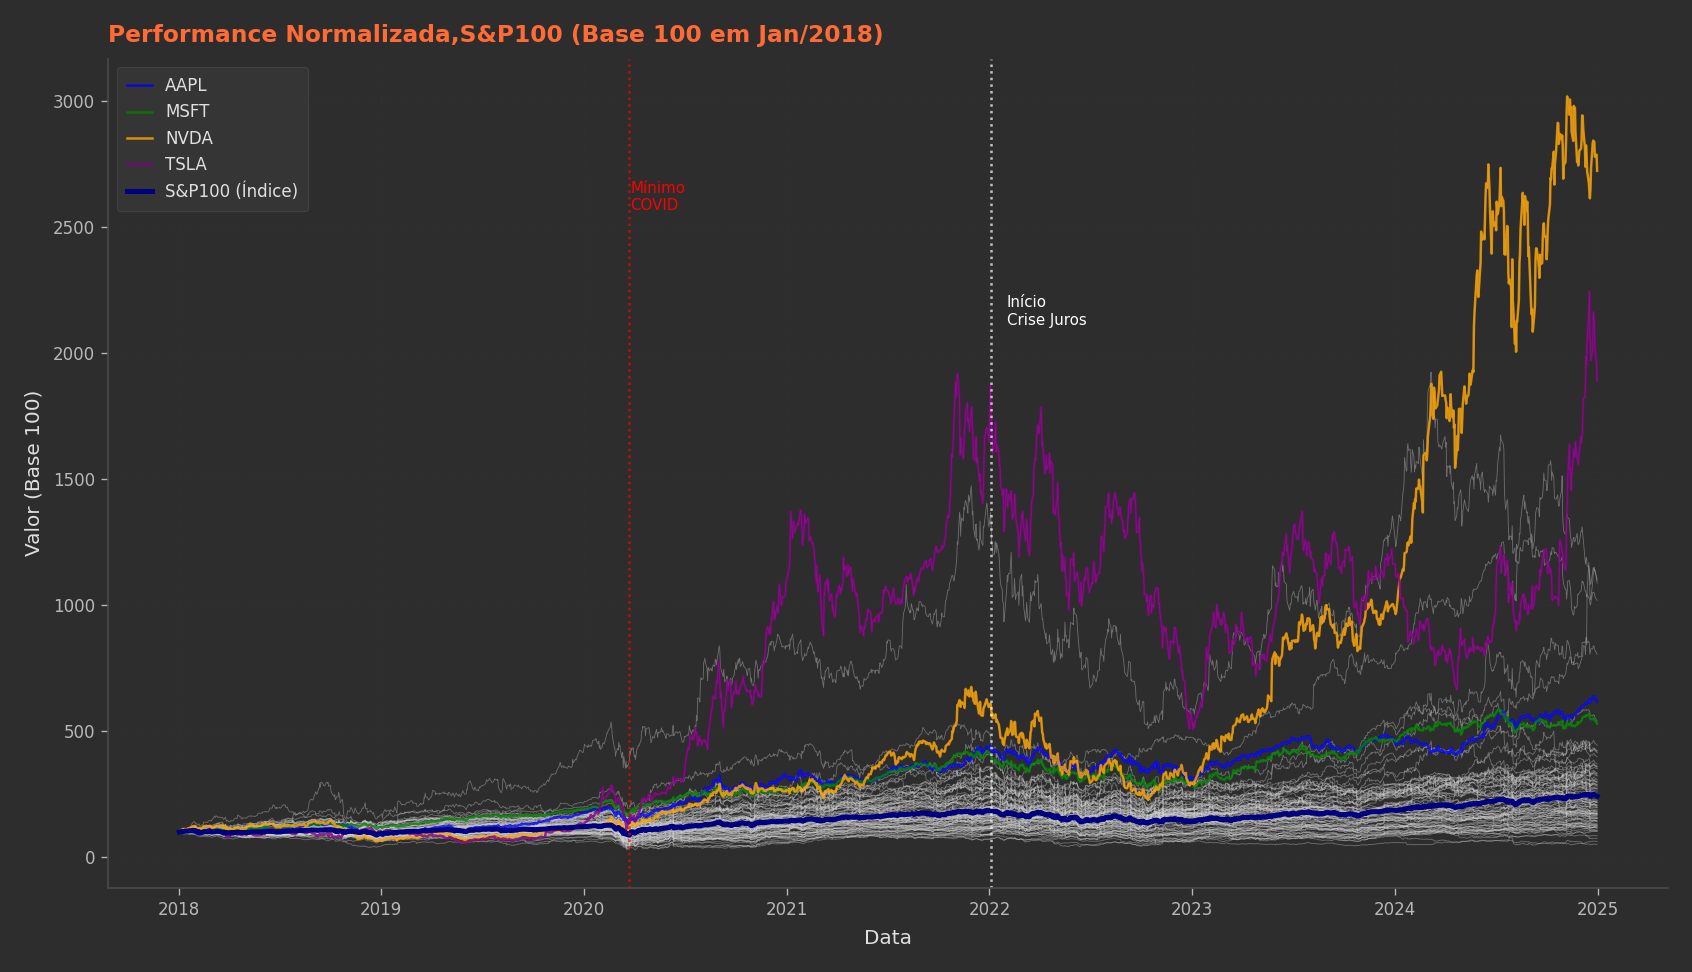

In [ ]:
# Performance normalizada: todos começam em 100 no início do período
precos_norm_sp = (dados_sp100_clean / dados_sp100_clean.iloc[0] * 100)
indice_norm_sp = (indice_sp100 / indice_sp100.iloc[0] * 100)

plt.figure(figsize=(14, 8))

# Ações individuais em cinza claro (fundo)
for col in precos_norm_sp.columns:
  plt.plot(precos_norm_sp.index, precos_norm_sp[col],
    color='lightgray', linewidth=0.5, alpha=0.4)

# Destacar algumas ações relevantes
destaques = ['AAPL', 'MSFT', 'NVDA', 'TSLA']
cores_dest = ['blue', 'green', 'orange', 'purple']
for acao, cor in zip(destaques, cores_dest):
  if acao in precos_norm_sp.columns:
   plt.plot(precos_norm_sp.index, precos_norm_sp[acao],
      color=cor, linewidth=1.5, label=acao, alpha=0.8)

# Índice em destaque total
plt.plot(indice_norm_sp.index, indice_norm_sp,
  color='navy', linewidth=3, label='S&P100 (Índice)')

# Marcar eventos importantes
plt.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle=':', linewidth=1.5, alpha=0.7)
plt.text(pd.Timestamp('2020-03-25'), precos_norm_sp.max().max()*0.85, 'Mínimo\nCOVID',
  color='red', fontsize=9)

plt.axvline(pd.Timestamp('2022-01-03'), color='white', linestyle=':', linewidth=1.5, alpha=0.7)
plt.text(pd.Timestamp('2022-02-01'), precos_norm_sp.max().max()*0.70, 'Início\nCrise Juros',
  color='white', fontsize=9)

plt.title('Performance Normalizada,S&P100 (Base 100 em Jan/2018)',
  fontsize=14, fontweight='bold')
plt.ylabel('Valor (Base 100)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('performance_normalizada_sp100.png', dpi=150)
plt.show()

####3.2.2 Estatísticas Descritivas dos Retornos

```
# Isto está formatado como código
```



TOP 10,Maior Retorno Anualizado (S&P100):
Ticker
NVDA    61.5288
TSLA    57.3288
AVGO    39.0774
LLY     35.0530
AAPL    29.5142
AMD     25.9680
AMAT    25.6006
COST    24.8390
LRCX    24.3408
NOW     23.9530
Name: Retorno médio anualizado (%), dtype: float64

TOP 10,Menor Volatilidade Anualizada (S&P100):
Ticker
JNJ     19.4632
CL      20.2845
KO      20.3413
PG      20.5084
VZ      20.7906
PEP     21.2868
MDLZ    21.4127
WMT     21.7876
MCD     22.6949
MRK     23.0592
Name: Volatilidade anualizada (%), dtype: float64

TOP 10,Melhor Sharpe Aproximado (S&P100):
Ticker
NVDA    1.1860
LLY     1.1292
COST    1.0632
AVGO    0.9638
AAPL    0.9555
TSLA    0.8796
WMT     0.8655
MSFT    0.7557
ABBV    0.7451
TMUS    0.7282
Name: Sharpe aprox. anualizado, dtype: float64


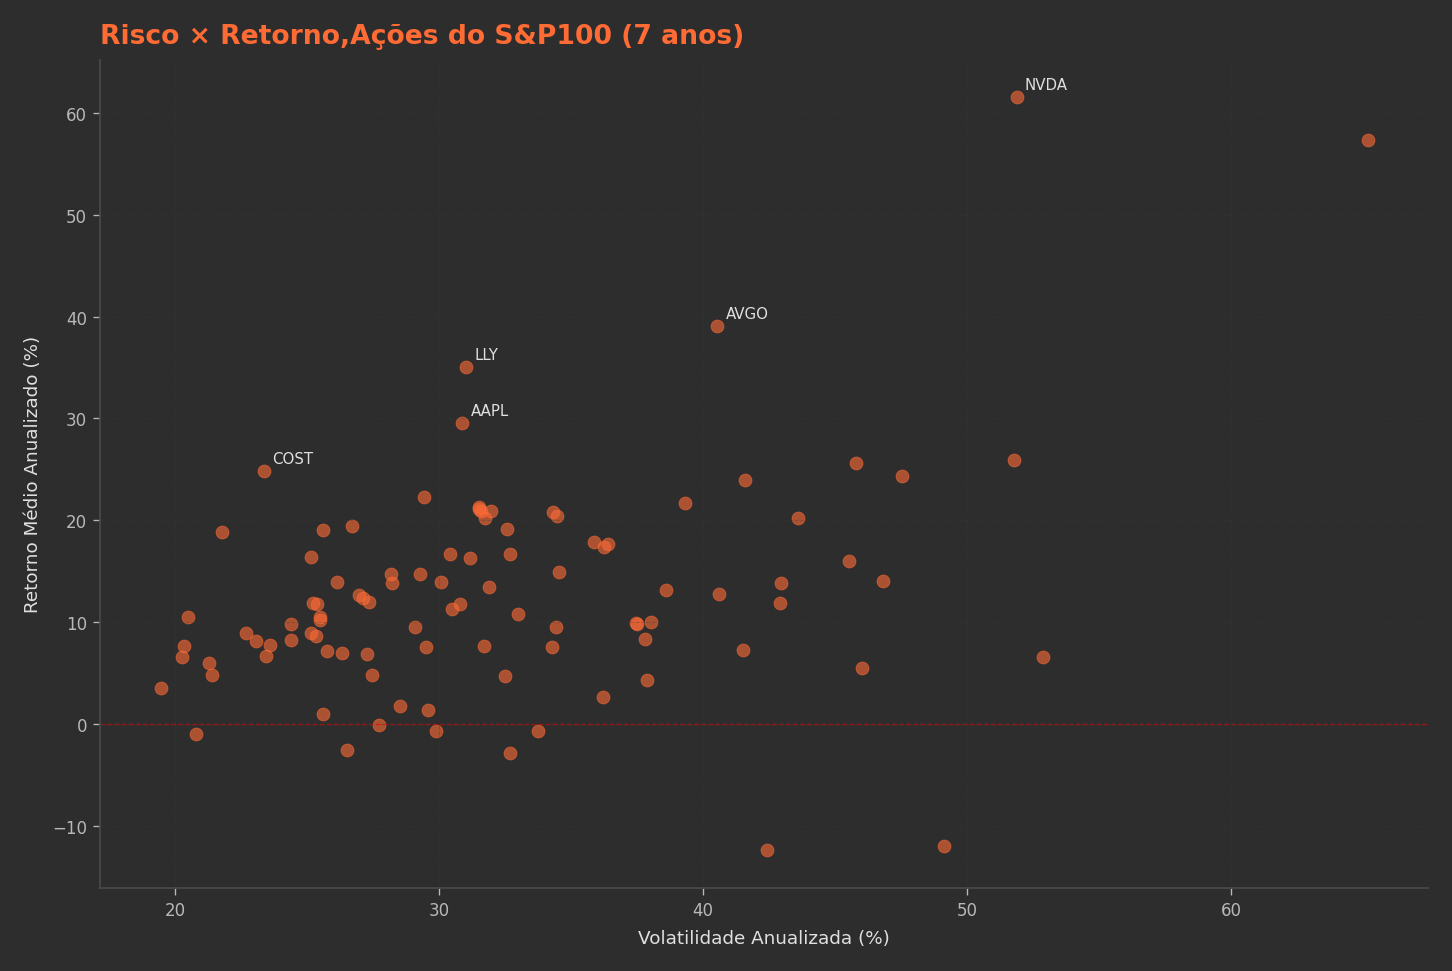

In [ ]:
# Estatísticas completas dos retornos,por ação
stats = pd.DataFrame({
'Retorno médio diário (%)': ret_sp100_clean.mean() * 100,
'Retorno médio anualizado (%)': ret_sp100_clean.mean() * 252 * 100,
'Volatilidade diária (%)': ret_sp100_clean.std() * 100,
'Volatilidade anualizada (%)': ret_sp100_clean.std() * np.sqrt(252) * 100,
'Sharpe aprox. anualizado': (
ret_sp100_clean.mean() / ret_sp100_clean.std() * np.sqrt(252)),
'Retorno mínimo diário (%)': ret_sp100_clean.min() * 100,
'Retorno máximo diário (%)': ret_sp100_clean.max() * 100,
'Assimetria (skewness)': ret_sp100_clean.skew(),
'Curtose (kurtosis)': ret_sp100_clean.kurtosis(),
'Dias negociados': ret_sp100_clean.count(),
}).round(4)
# Top 10 maior retorno médio anualizado
print('TOP 10,Maior Retorno Anualizado (S&P100):')
print(stats['Retorno médio anualizado (%)'].sort_values(ascending=False).head(10))
# Top 10 menor volatilidade (mais estáveis)
print('\nTOP 10,Menor Volatilidade Anualizada (S&P100):')
print(stats['Volatilidade anualizada (%)'].sort_values().head(10))
# Top 10 melhor Sharpe (melhor retorno ajustado por risco)
print('\nTOP 10,Melhor Sharpe Aproximado (S&P100):')
print(stats['Sharpe aprox. anualizado'].sort_values(ascending=False).head(10))
# Gráfico risco vs. retorno (Fronteira de dispersão)
plt.figure(figsize=(12, 8))
plt.scatter(stats['Volatilidade anualizada (%)'],
stats['Retorno médio anualizado (%)'],
alpha=0.6, s=60, color='#FF6B35')
# Anotar algumas ações de destaque
top_acoes = stats['Sharpe aprox. anualizado'].sort_values(ascending=False).head(5).index
for acao in top_acoes:
    plt.annotate(acao,
    (stats.loc[acao, 'Volatilidade anualizada (%)'],
    stats.loc[acao, 'Retorno médio anualizado (%)']),
    textcoords='offset points', xytext=(5,5), fontsize=9)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
plt.title('Risco × Retorno,Ações do S&P100 (7 anos)', fontweight='bold')
plt.xlabel('Volatilidade Anualizada (%)')
plt.ylabel('Retorno Médio Anualizado (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('risco_retorno_sp100.png', dpi=150)
plt.show()

####3.2.3 Retorno por Período,Identificando Crises

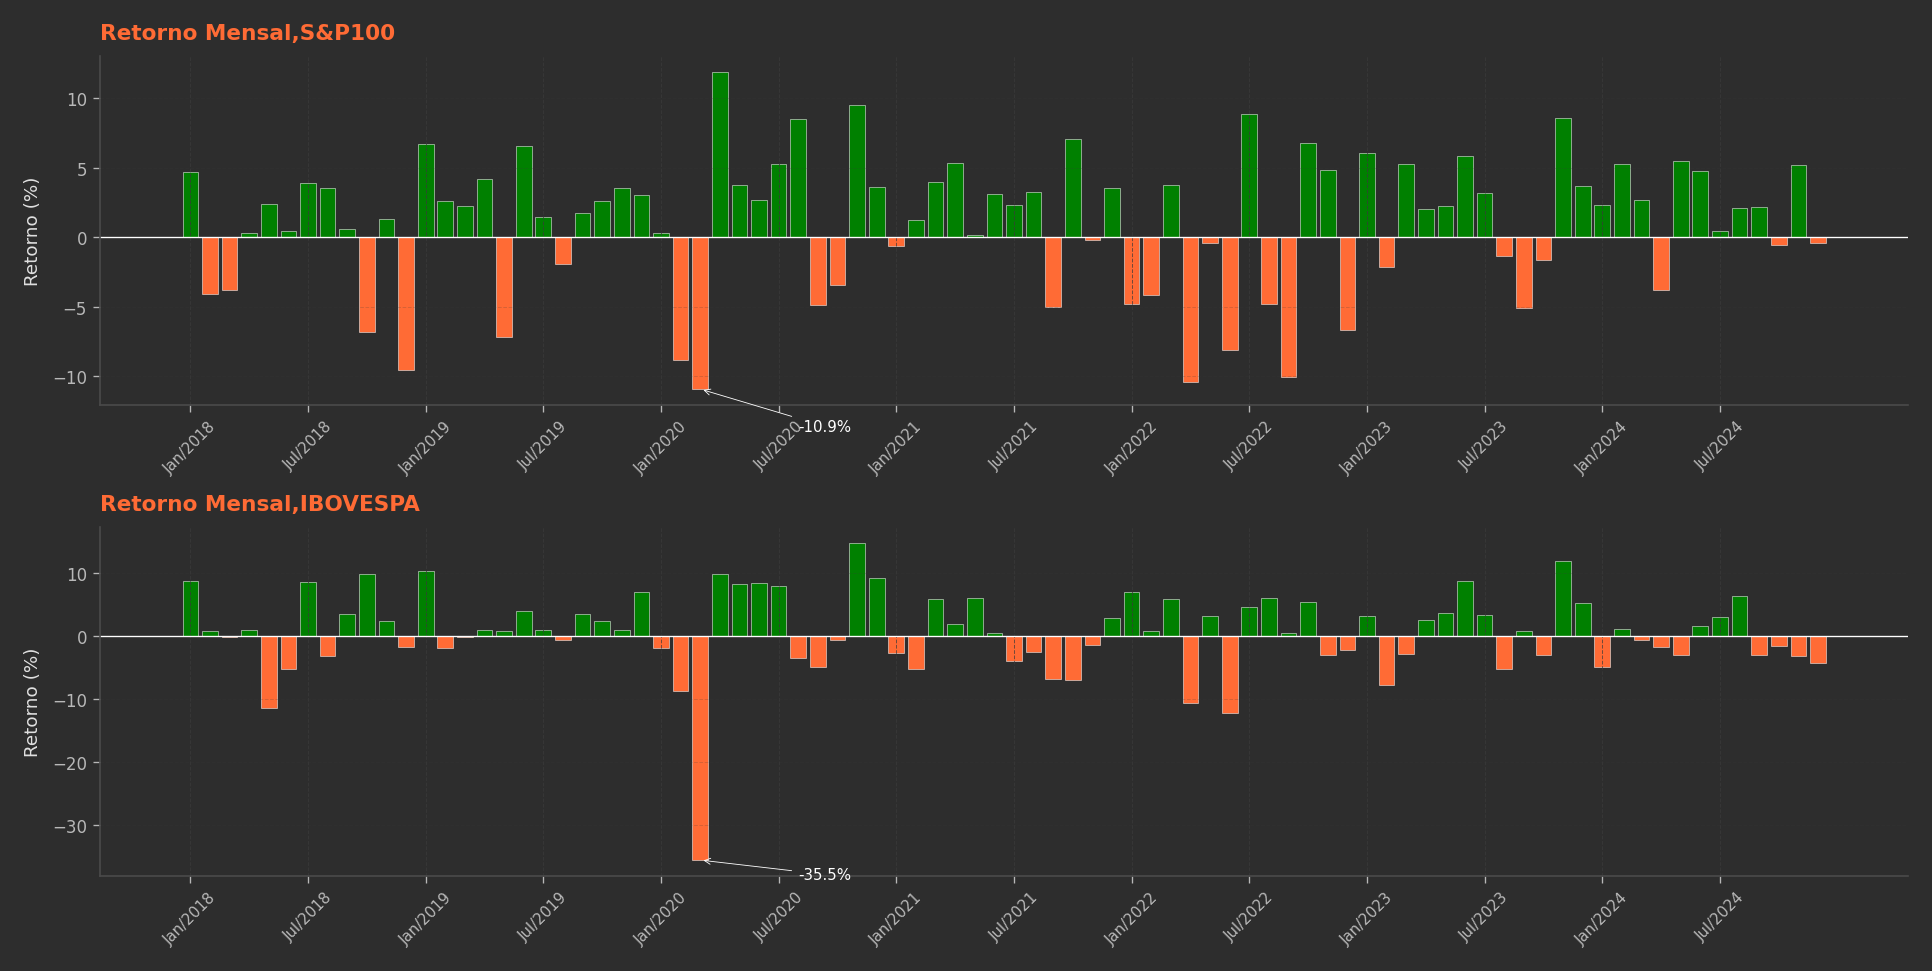


Retorno anual S&P100:
Ticker       ^OEX
Date             
2018-12-31  -8.14
2019-12-31  28.40
2020-12-31  12.43
2021-12-31  26.41
2022-12-31 -24.53
2023-12-31  29.62
2024-12-31  28.00

Retorno anual IBOVESPA:
Ticker      ^BVSP
Date             
2018-12-31  10.19
2019-12-31  29.84
2020-12-31  -7.33
2021-12-31 -14.03
2022-12-31   2.69
2023-12-31  20.18
2024-12-31 -11.10


In [ ]:
# Retorno mensal do índice
ret_mensal_sp = ret_idx_sp.resample('ME').sum() # soma dos retornos diários do mês
ret_mensal_ib = ret_idx_ib.resample('ME').sum()
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
for ax, ret, titulo, cor_pos, cor_neg in [
(axes[0], ret_mensal_sp, 'S&P100', 'green', '#FF6B35'),
(axes[1], ret_mensal_ib, 'IBOVESPA', 'green', '#FF6B35'),
]:
    cores = [cor_pos if r > 0 else cor_neg for r in ret.squeeze().values]
    ax.bar(range(len(ret)), ret.squeeze().values * 100, color=cores, edgecolor='white', linewidth=0.3)
    ax.axhline(0, color='white', linewidth=0.8)
    ax.set_title(f'Retorno Mensal,{titulo}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Retorno (%)')
    ax.set_xticks(range(0, len(ret), 6))
    ax.set_xticklabels(ret.index[::6].strftime('%b/%Y'), rotation=45, fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')
    # Anotar o pior mês
    pior_idx = ret.squeeze().values.argmin()
    pior_val = ret.squeeze().values[pior_idx] * 100
    ax.annotate(f'{pior_val:.1f}%',
    xy=(pior_idx, pior_val), xytext=(pior_idx+5, pior_val-3),
    arrowprops=dict(arrowstyle='->', color='white'),
    fontsize=9, color='white')
plt.tight_layout()
plt.savefig('retorno_mensal_indices.png', dpi=150)
plt.show()
# Retorno acumulado por ano
ret_anual_sp = (1 + ret_idx_sp).resample('YE').prod() - 1
ret_anual_ib = (1 + ret_idx_ib).resample('YE').prod() - 1
print('\nRetorno anual S&P100:')
print((ret_anual_sp * 100).round(2))
print('\nRetorno anual IBOVESPA:')
print((ret_anual_ib * 100).round(2))

 3.2.4 Correlação com o Índice,A Análise Central do Projeto

--------------------------------------------------
TOP 15: Ações mais correlacionadas com o S&P100:
        Correlação
Ticker            
MSFT        0.8602
AAPL        0.8249
BLK         0.7878
GOOGL       0.7778
GOOG        0.7757
INTU        0.7710
TXN         0.7650
MA          0.7646
ACN         0.7612
V           0.7592
AMAT        0.7369
NVDA        0.7350
MS          0.7236
LRCX        0.7221
AVGO        0.7201

BOTTOM 10: Ações menos correlacionadas com o S&P100:
        Correlação
Ticker            
WMT         0.4494
CVS         0.4454
LLY         0.4424
ABBV        0.4374
MO          0.4358
MRK         0.4259
PFE         0.4146
VZ          0.3974
BMY         0.3952
GILD        0.3788

21.4% das ações têm correlação > 0.7 com o índice
--------------------------------------------------
TOP 15: Ações mais correlacionadas com o IBOV:
           Correlação
Ticker               
AAPL34.SA      0.6088
MSFT34.SA      0.5976
NVDC34.SA      0.5336
GOGL34.SA      0.5320
GOGL35.SA     

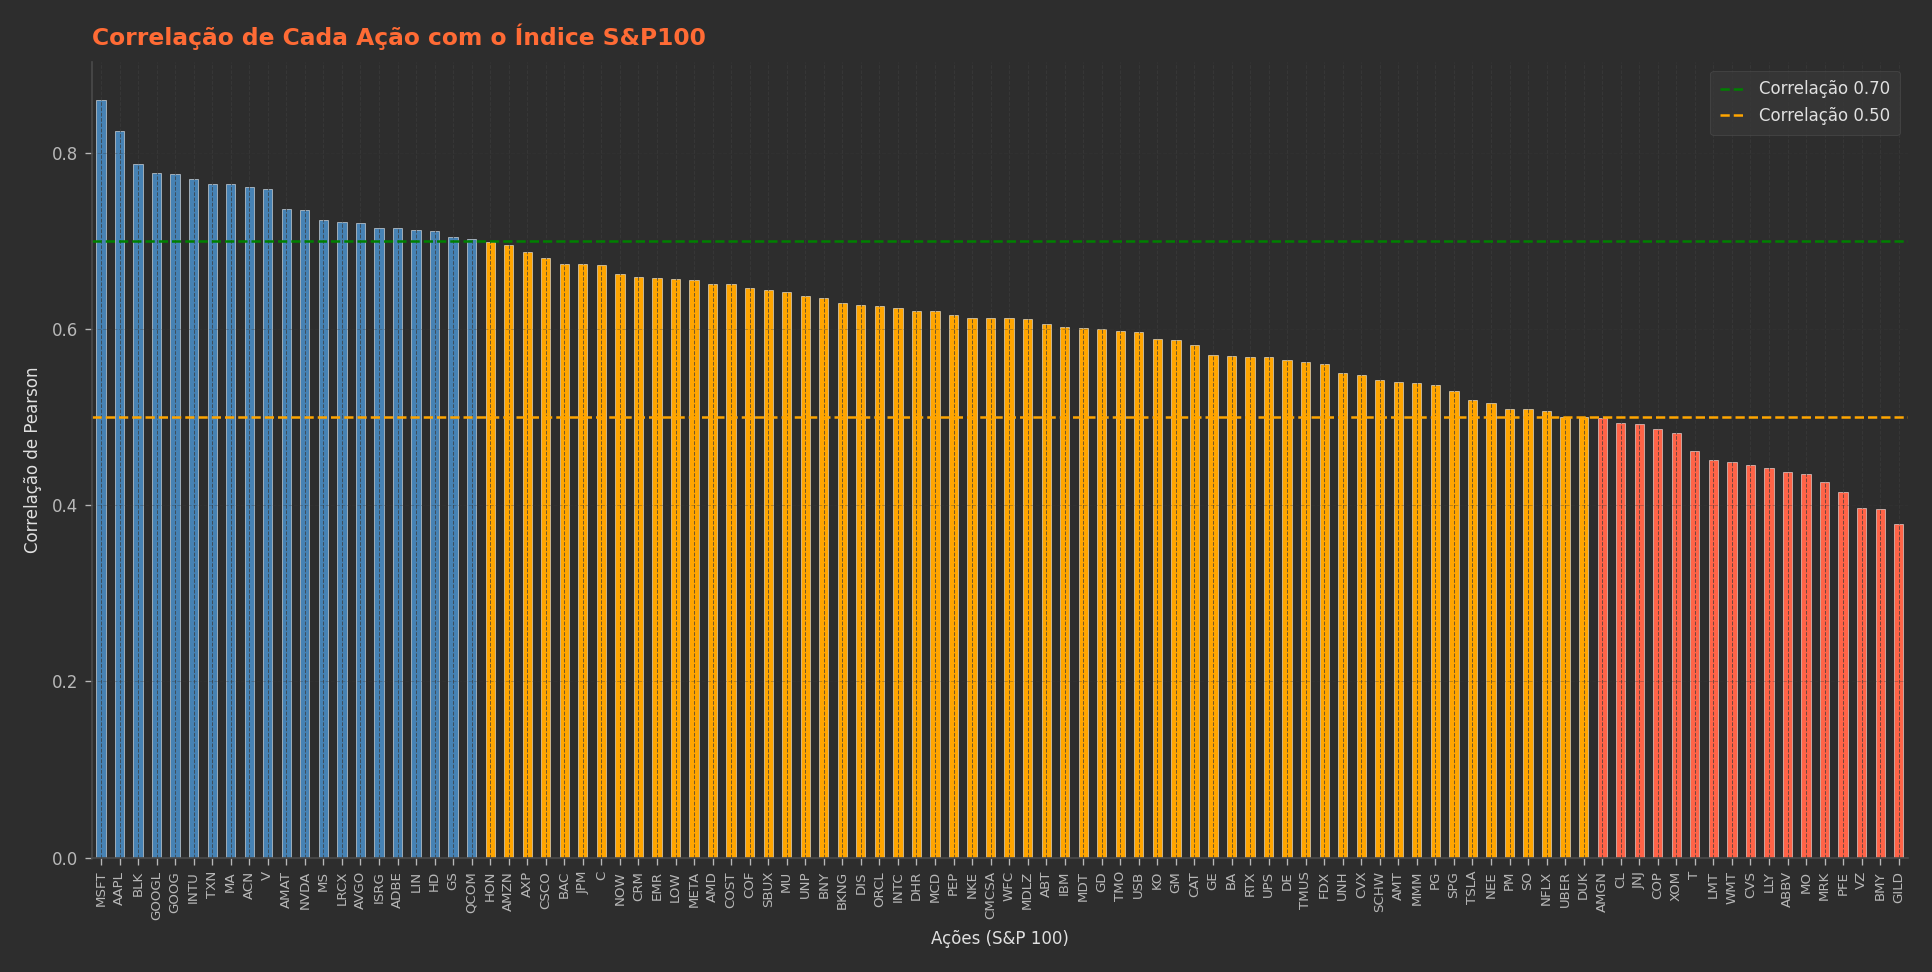

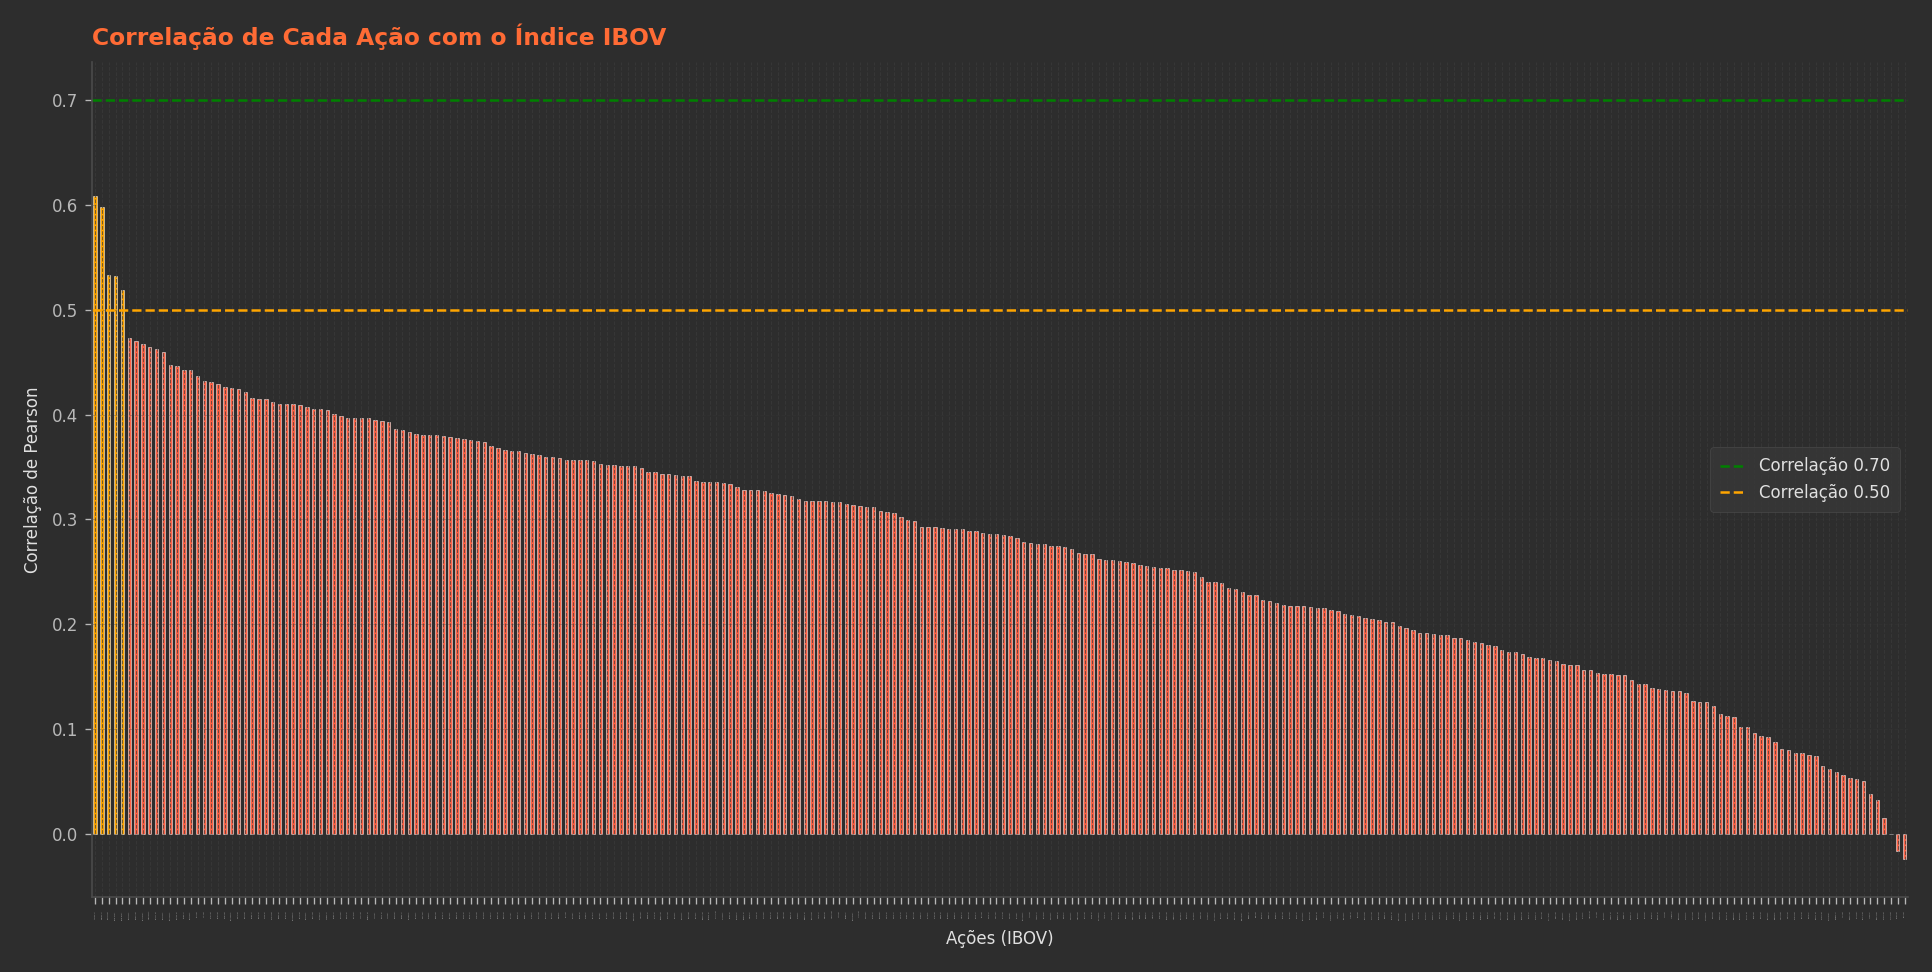

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------SP100
# --- 1. PREPARAÇÃO E ALINHAMENTO ---
# Removendo Timezones para garantir que a interseção funcione (evita gráfico zerado)
ret_sp100_clean.index = pd.to_datetime(ret_sp100_clean.index).tz_localize(None)
ret_idx_sp.index = pd.to_datetime(ret_idx_sp.index).tz_localize(None)

datas_comuns_sp = ret_sp100_clean.index.intersection(ret_idx_sp.index)
ret_acoes_al_sp = ret_sp100_clean.loc[datas_comuns_sp]
ret_idx_al_sp = ret_idx_sp.loc[datas_comuns_sp]

# Garantindo que o índice seja uma Series para o cálculo
serie_idx_sp = ret_idx_al_sp.iloc[:, 0] if isinstance(ret_idx_al_sp, pd.DataFrame) else ret_idx_al_sp

# --- 2. CÁLCULO DA CORRELAÇÃO ---
# Calculamos e removemos NaNs (ações sem dados no período)
corr_com_idx_sp = ret_acoes_al_sp.corrwith(serie_idx_sp).dropna().sort_values(ascending=False)

# --- 3. PRINTS (TOP 15 E BOTTOM 10) ---
print("-" * 50)
print('TOP 15: Ações mais correlacionadas com o S&P100:')
print(corr_com_idx_sp.head(15).to_frame(name='Correlação').round(4))

print('\nBOTTOM 10: Ações menos correlacionadas com o S&P100:')
print(corr_com_idx_sp.tail(10).to_frame(name='Correlação').round(4))

# --- 4. CÁLCULO DA PORCENTAGEM ---
# Quantos % das ações têm correlação > 0.7?
if not corr_com_idx_sp.empty:
    pct_alta_corr = (corr_com_idx_sp > 0.7).mean() * 100
    print(f'\n{pct_alta_corr:.1f}% das ações têm correlação > 0.7 com o índice')
else:
    print("\nERRO: Não foi possível calcular a porcentagem (dados vazios).")

# --- 5. GRÁFICO DE CORRELAÇÃO ---
if not corr_com_idx_sp.empty:
    plt.figure(figsize=(16, 8))

    # Definindo as cores com base nos limites
    cores = ['steelblue' if c > 0.7 else ('orange' if c > 0.5 else 'tomato')
             for c in corr_com_idx_sp.values]

    corr_com_idx_sp.plot(kind='bar', color=cores, edgecolor='white', linewidth=0.3)

    # Linhas de referência
    plt.axhline(0.7, color='green', linestyle='--', linewidth=1.5, label='Correlação 0.70')
    plt.axhline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Correlação 0.50')

    plt.title('Correlação de Cada Ação com o Índice S&P100', fontweight='bold', fontsize=14)
    plt.xlabel('Ações (S&P 100)', fontsize=10)
    plt.ylabel('Correlação de Pearson', fontsize=10)
    plt.xticks(rotation=90, fontsize=8)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt

  #----------------------------------------------------------------------------IBOV

# Removendo Timezones para garantir que a interseção funcione (evita gráfico zerado)
ret_ibov_clean.index = pd.to_datetime(ret_ibov_clean.index).tz_localize(None)
ret_idx_ib.index = pd.to_datetime(ret_idx_ib.index).tz_localize(None)


datas_comuns = ret_ibov_clean.index.intersection(ret_idx_ib.index)
ret_acoes_al_ibov = ret_ibov_clean.loc[datas_comuns]
ret_idx_al_ibov = ret_idx_ib.loc[datas_comuns]


# Garantindo que o índice seja uma Series para o cálculo
serie_idx_ibov = ret_idx_al_ibov.iloc[:, 0] if isinstance(ret_idx_al_ibov, pd.DataFrame) else ret_idx_al_ibov


# --- 2. CÁLCULO DA CORRELAÇÃO ---
# Calculamos e removemos NaNs (ações sem dados no período)
corr_com_idx_ibov = ret_acoes_al_ibov.corrwith(serie_idx_ibov).dropna().sort_values(ascending=False)


# --- 3. PRINTS (TOP 15 E BOTTOM 10) ---
print("-" * 50)
print('TOP 15: Ações mais correlacionadas com o IBOV:')
print(corr_com_idx_ibov.head(15).to_frame(name='Correlação').round(4))


print('\nBOTTOM 10: Ações menos correlacionadas com o IBOV:')
print(corr_com_idx_ibov.tail(10).to_frame(name='Correlação').round(4))


# --- 4. CÁLCULO DA PORCENTAGEM ---
# Quantos % das ações têm correlação > 0.7?
if not corr_com_idx_ibov.empty:
    pct_alta_corr_ibov = (corr_com_idx_ibov > 0.7).mean() * 100
    print(f'\n{pct_alta_corr_ibov:.1f}% das ações têm correlação > 0.7 com o índice')
else:
    print("\nERRO: Não foi possível calcular a porcentagem (dados vazios).")


# --- 5. GRÁFICO DE CORRELAÇÃO ---
if not corr_com_idx_ibov.empty:
    plt.figure(figsize=(16, 8))

    # Definindo as cores com base nos limites
    cores_ibov = ['steelblue' if c > 0.7 else ('orange' if c > 0.5 else 'tomato')
             for c in corr_com_idx_ibov.values]

    corr_com_idx_ibov.plot(kind='bar', color=cores_ibov, edgecolor='white', linewidth=0.3)

    # Linhas de referência
    plt.axhline(0.7, color='green', linestyle='--', linewidth=1.5, label='Correlação 0.70')
    plt.axhline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Correlação 0.50')

    plt.title('Correlação de Cada Ação com o Índice IBOV', fontweight='bold', fontsize=14)
    plt.xlabel('Ações (IBOV)', fontsize=10)
    plt.ylabel('Correlação de Pearson', fontsize=10)
    plt.xticks(rotation=90, fontsize=0)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt

#### 3.3 Correlação Entre Ações e Análise por Setor

[3.3.1 Matriz de Correlação Entre Ações]

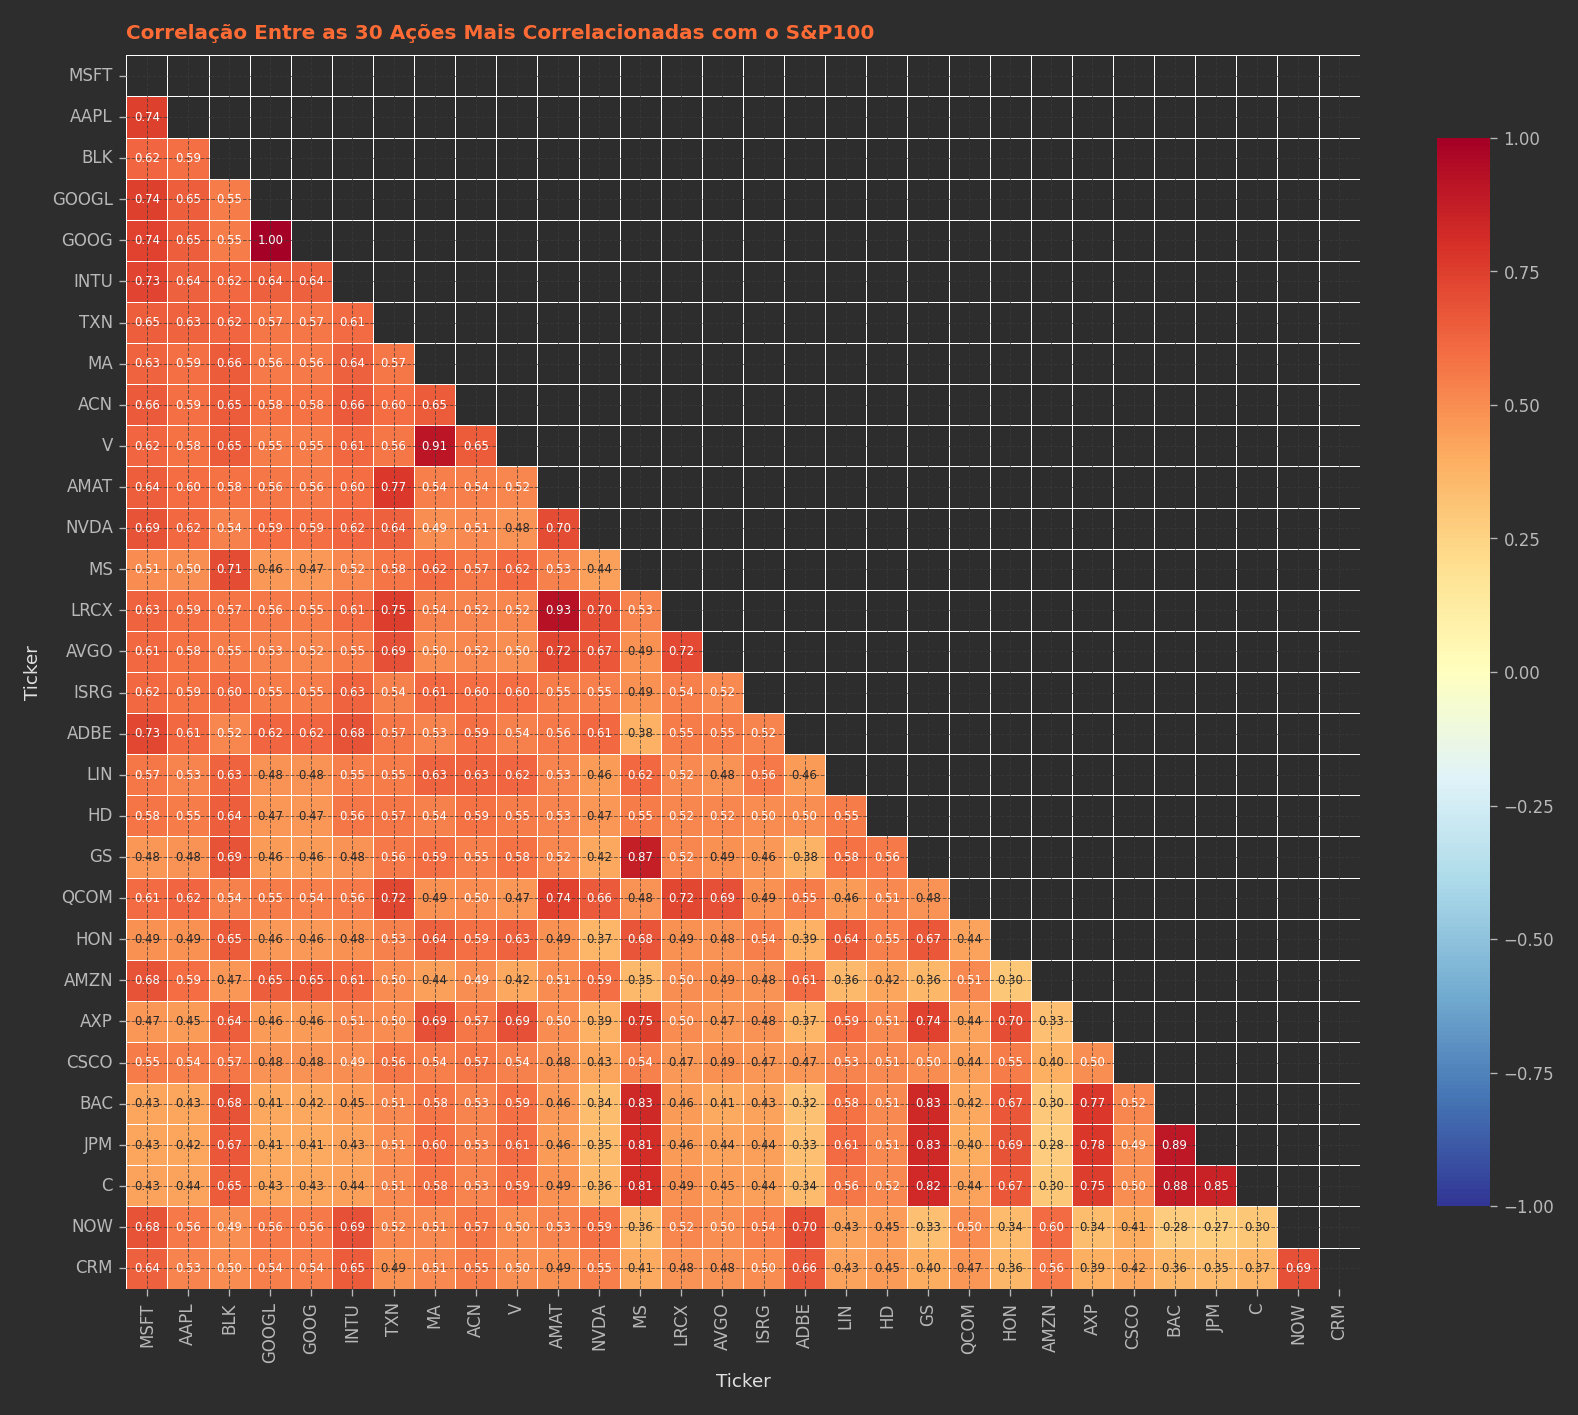

Pares com correlação > 0.90: 3
Ação 1 Ação 2  Correlação
  GOOG  GOOGL       0.996
  AMAT   LRCX       0.927
    MA      V       0.908


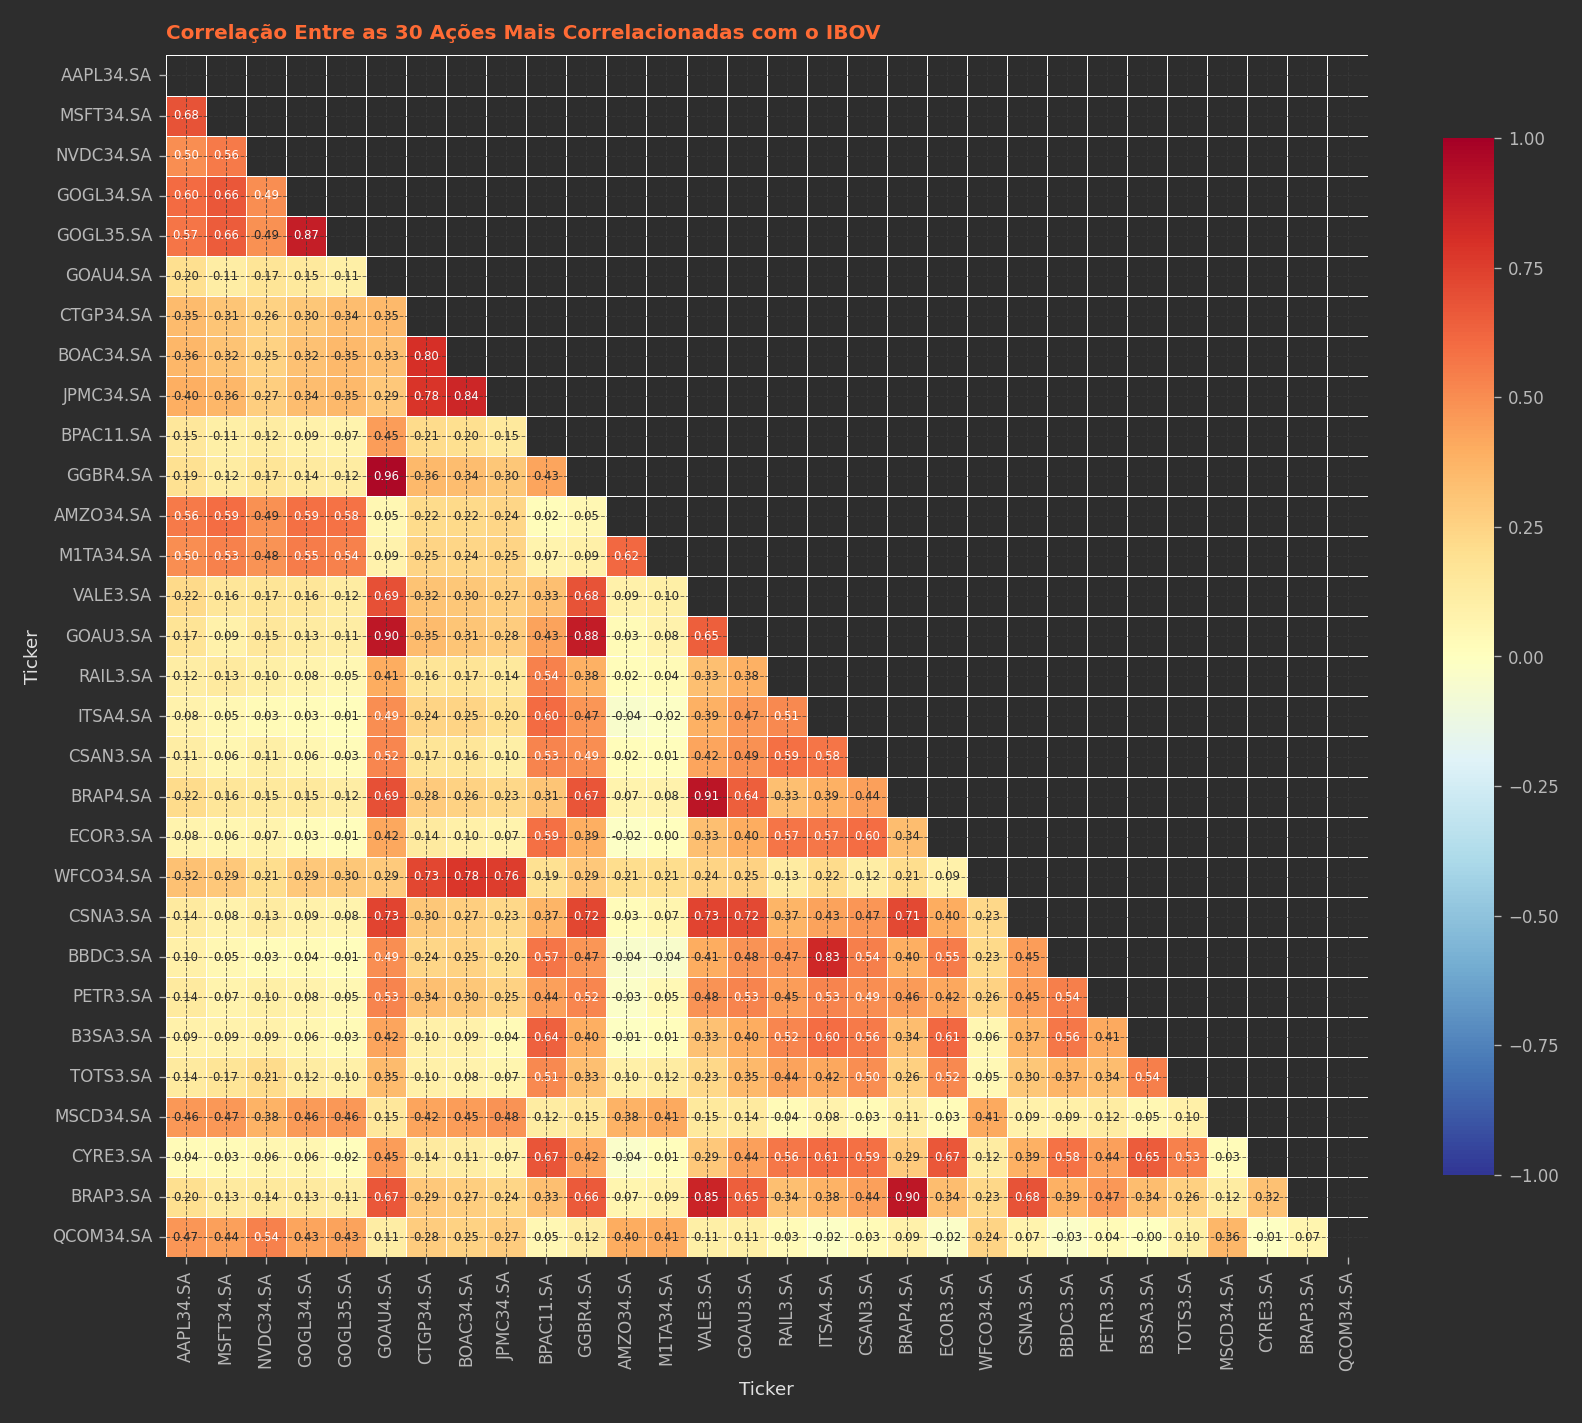

Pares com correlação > 0.90: 11
  Ação 1   Ação 2  Correlação
PETR3.SA PETR4.SA       0.974
BBDC3.SA BBDC4.SA       0.964
GGBR4.SA GOAU4.SA       0.962
AXIA3.SA AXIA6.SA       0.954
ITUB3.SA ITUB4.SA       0.951
USIM3.SA USIM5.SA       0.911
GGBR3.SA GGBR4.SA       0.911
ITSA4.SA ITUB4.SA       0.907
BRAP4.SA VALE3.SA       0.907
GOAU3.SA GOAU4.SA       0.901
BRAP3.SA BRAP4.SA       0.900


In [ ]:
# Removendo Timezones para garantir que a interseção funcione (evita gráfico zerado)
ret_sp100_clean.index = pd.to_datetime(ret_sp100_clean.index).tz_localize(None)
ret_idx_sp.index = pd.to_datetime(ret_idx_sp.index).tz_localize(None)

datas_comuns_sp = ret_sp100_clean.index.intersection(ret_idx_sp.index)
ret_acoes_al_sp = ret_sp100_clean.loc[datas_comuns_sp]
ret_idx_al_sp = ret_idx_sp.loc[datas_comuns_sp]

# Garantindo que o índice seja uma Series para o cálculo
serie_idx_sp = ret_idx_al_sp.iloc[:, 0] if isinstance(ret_idx_al_sp, pd.DataFrame) else ret_idx_al_sp

# --- 2. CÁLCULO DA CORRELAÇÃO ---
# Calculamos e removemos NaNs (ações sem dados no período)
corr_com_idx_sp = ret_acoes_al_sp.corrwith(serie_idx_sp).dropna().sort_values(ascending=False)

corr_matrix = ret_sp100_clean.corr()
# Heatmap,para muitas ações, use uma amostra das mais representativas
# Selecionar as 30 ações com maior correlação com o índice
top30 = corr_com_idx_sp.head(30).index
corr_top30 = ret_sp100_clean[top30].corr()

plt.figure(figsize=(14, 12))
import numpy as np
mask = np.triu(np.ones_like(corr_top30, dtype=bool)) # mostrar só triângulo inferior
sns.heatmap(
  corr_top30,
  mask=mask,
  annot=True, fmt='.2f',
  cmap='RdYlBu_r',
  center=0, square=True,
  linewidths=0.3,
  vmin=-1, vmax=1,
  cbar_kws={'shrink': 0.8},
  annot_kws={'size': 7}
)
plt.title('Correlação Entre as 30 Ações Mais Correlacionadas com o S&P100',
fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_correlacao_acoes.png', dpi=150, bbox_inches='tight')
plt.show()

# Encontrar pares com correlação muito alta (potencialmente redundantes)
pares_alta_corr = []
for i in range(len(corr_matrix.columns)):
  for j in range(i+1, len(corr_matrix.columns)):
    r = corr_matrix.iloc[i, j]
    if r > 0.90:
      pares_alta_corr.append({
        'Ação 1': corr_matrix.columns[i],
        'Ação 2': corr_matrix.columns[j],
        'Correlação': round(r, 3)
        })
df_pares = pd.DataFrame(pares_alta_corr).sort_values('Correlação', ascending=False)
print(f'Pares com correlação > 0.90: {len(df_pares)}')
print(df_pares.head(20).to_string(index=False))


#--------------------------------------------------------------------IBOV
# Removendo Timezones para garantir que a interseção funcione (evita gráfico zerado)
ret_ibov_clean.index = pd.to_datetime(ret_ibov_clean.index).tz_localize(None)
ret_idx_sp.index = pd.to_datetime(ret_idx_sp.index).tz_localize(None)


datas_comuns_sp = ret_ibov_clean.index.intersection(ret_idx_sp.index)
ret_acoes_al_sp = ret_ibov_clean.loc[datas_comuns_sp]
ret_idx_al_sp = ret_idx_sp.loc[datas_comuns_sp]


# Garantindo que o índice seja uma Series para o cálculo
serie_idx_sp = ret_idx_al_sp.iloc[:, 0] if isinstance(ret_idx_al_sp, pd.DataFrame) else ret_idx_al_sp


# --- 2. CÁLCULO DA CORRELAÇÃO ---
# Calculamos e removemos NaNs (ações sem dados no período)
corr_com_idx_sp = ret_acoes_al_sp.corrwith(serie_idx_sp).dropna().sort_values(ascending=False)


corr_matrix = ret_ibov_clean.corr()
# Heatmap,para muitas ações, use uma amostra das mais representativas
# Selecionar as 30 ações com maior correlação com o índice
top30 = corr_com_idx_sp.head(30).index
corr_top30 = ret_ibov_clean[top30].corr()


plt.figure(figsize=(14, 12))
import numpy as np
mask = np.triu(np.ones_like(corr_top30, dtype=bool)) # mostrar só triângulo inferior
sns.heatmap(
  corr_top30,
  mask=mask,
  annot=True, fmt='.2f',
  cmap='RdYlBu_r',
  center=0, square=True,
  linewidths=0.3,
  vmin=-1, vmax=1,
  cbar_kws={'shrink': 0.8},
  annot_kws={'size': 7}
)
plt.title('Correlação Entre as 30 Ações Mais Correlacionadas com o IBOV',
fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_correlacao_acoes.png', dpi=150, bbox_inches='tight')
plt.show()


# Encontrar pares com correlação muito alta (potencialmente redundantes)
pares_alta_corr = []
for i in range(len(corr_matrix.columns)):
  for j in range(i+1, len(corr_matrix.columns)):
    r = corr_matrix.iloc[i, j]
    if r > 0.90:
      pares_alta_corr.append({
        'Ação 1': corr_matrix.columns[i],
        'Ação 2': corr_matrix.columns[j],
        'Correlação': round(r, 3)
        })
df_pares = pd.DataFrame(pares_alta_corr).sort_values('Correlação', ascending=False)
print(f'Pares com correlação > 0.90: {len(df_pares)}')
print(df_pares.head(20).to_string(index=False))

######3.3.2 Análise por Setor da Economia


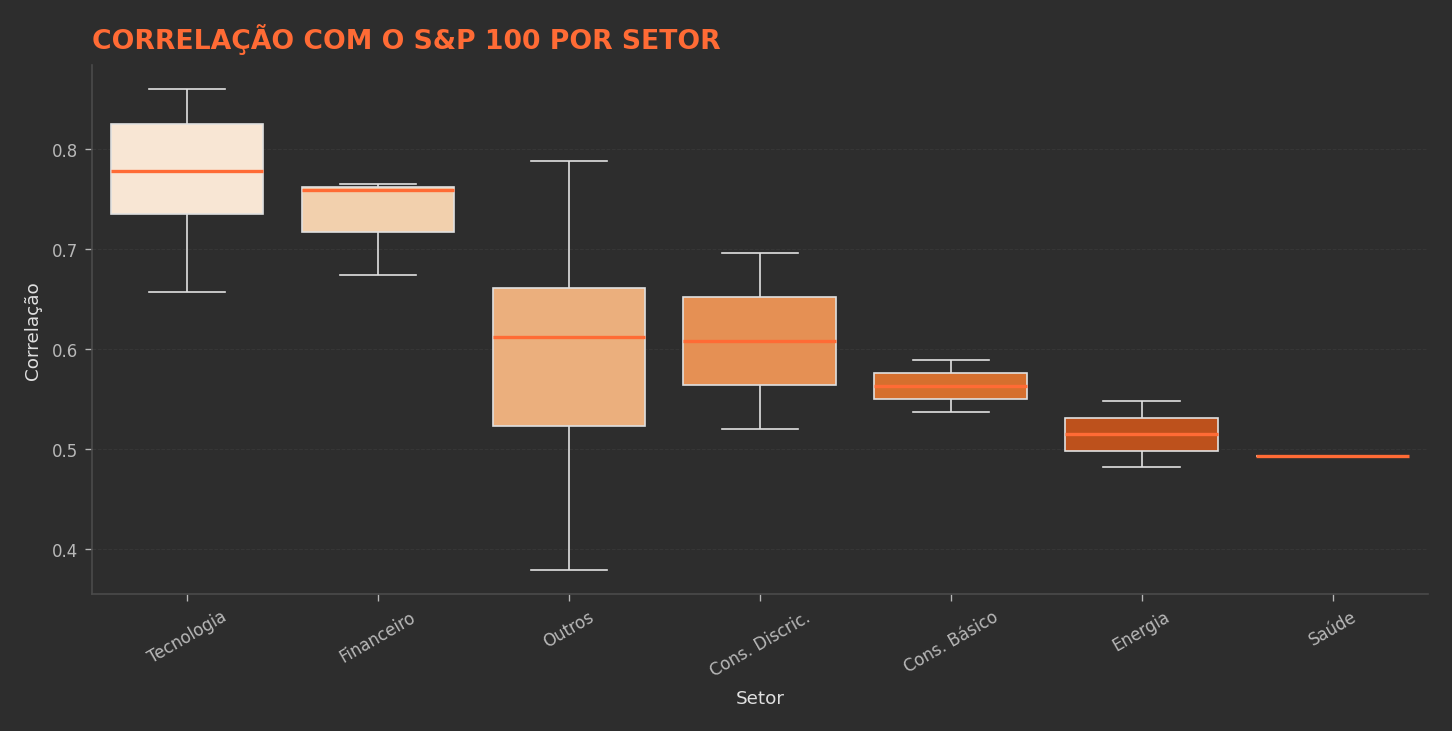

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. GARANTIR A IDENTIDADE VISUAL (Execute isso primeiro)
estilo_finor()

# 2. ALINHAMENTO E CÁLCULO (A parte que funcionava)
# Ajustamos as datas para evitar o erro de "gráfico zerado"
ret_sp100_clean.index = pd.to_datetime(ret_sp100_clean.index).tz_localize(None)
ret_idx_sp.index = pd.to_datetime(ret_idx_sp.index).tz_localize(None)

datas_comuns = ret_sp100_clean.index.intersection(ret_idx_sp.index)
ret_acoes_al = ret_sp100_clean.loc[datas_comuns]
ret_idx_al = ret_idx_sp.loc[datas_comuns]

# Cálculo da correlação
serie_idx = ret_idx_al.iloc[:, 0] if isinstance(ret_idx_al, pd.DataFrame) else ret_idx_al
corr_com_idx = ret_acoes_al.corrwith(serie_idx).dropna().sort_values(ascending=False)

# 3. MAPEAMENTO DE SETORES (S&P 100)
# Criamos o dicionário e limpamos os nomes das ações para garantir o match
setores_sp100 = {
    'AAPL': 'Tecnologia', 'MSFT': 'Tecnologia', 'NVDA': 'Tecnologia', 'GOOGL': 'Tecnologia',
    'AMZN': 'Cons. Discric.', 'TSLA': 'Cons. Discric.', 'META': 'Tecnologia',
    'JPM': 'Financeiro', 'V': 'Financeiro', 'MA': 'Financeiro', 'XOM': 'Energia',
    'CVX': 'Energia', 'PG': 'Cons. Básico', 'KO': 'Cons. Básico', 'JNJ': 'Saúde'
}

df_corr_setor = pd.DataFrame({
    'acao': corr_com_idx.index,
    'corr_idx': corr_com_idx.values
})

# Limpamos os tickers (tira .US, tira espaços) para o dicionário funcionar
df_corr_setor['ticker_limpo'] = df_corr_setor['acao'].astype(str).str.split('.').str[0].str.strip().str.upper()
df_corr_setor['setor'] = df_corr_setor['ticker_limpo'].map(setores_sp100).fillna('Outros')

# 4. O BOXPLOT (Versão com linhas visíveis no Dark Mode)
plt.figure(figsize=(12, 6))

setores_ord = df_corr_setor.groupby('setor')['corr_idx'].median().sort_values(ascending=False).index
c_linhas = '#E0E0E0' # Cinza claro para as bordas aparecerem

sns.boxplot(
    data=df_corr_setor,
    x='setor',
    y='corr_idx',
    order=setores_ord,
    palette='Oranges',
    boxprops=dict(edgecolor=c_linhas),
    whiskerprops=dict(color=c_linhas),
    capprops=dict(color=c_linhas),
    medianprops=dict(color='#FF6B35', linewidth=2),
    flierprops=dict(markeredgecolor=c_linhas)
)

plt.title('CORRELAÇÃO COM O S&P 100 POR SETOR')
plt.xlabel('Setor')
plt.ylabel('Correlação')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Resumo da Correlação por Setor (IBOV):
setor
Financeiro     0.7518
Petróleo       0.7395
Commodities    0.6517
Outros         0.3522
Name: corr_idx, dtype: float64


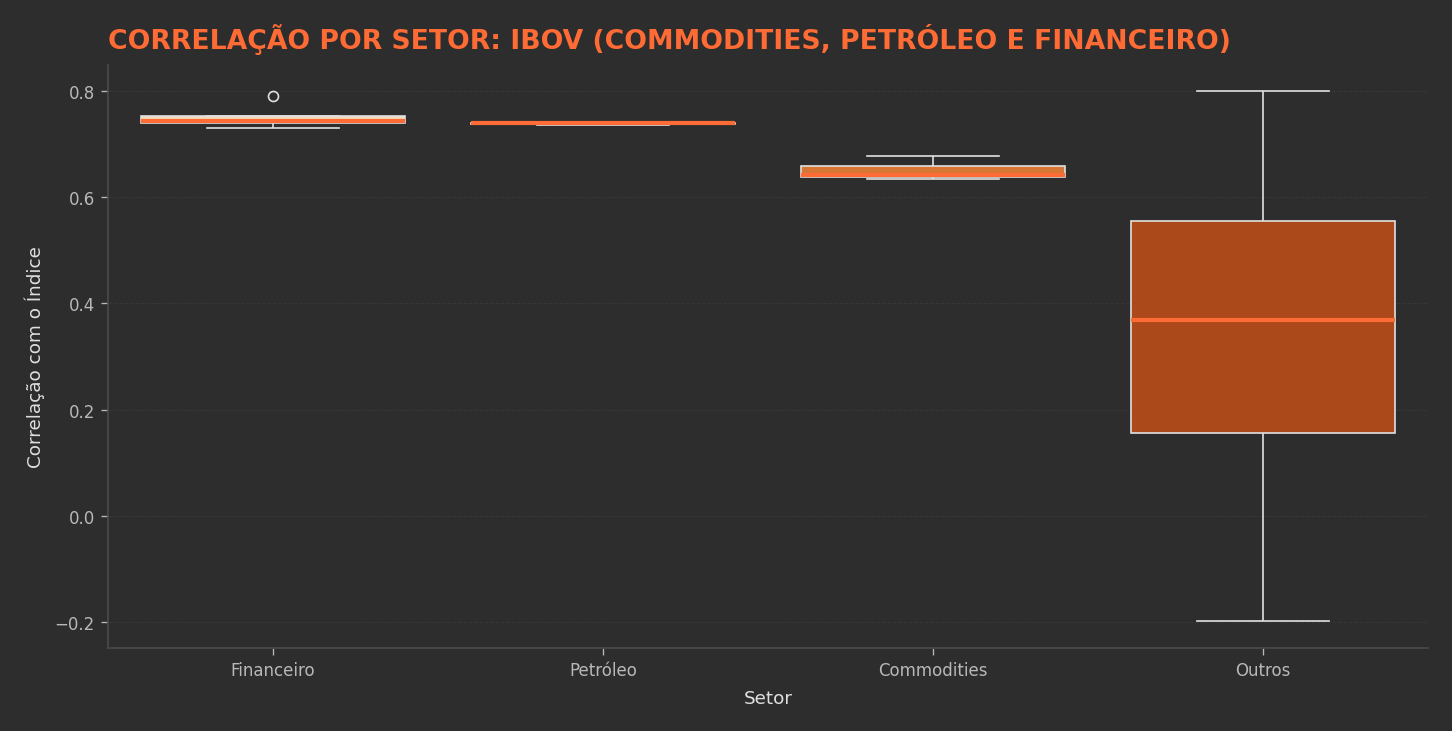

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dicionário de Setores focado no IBOV (conforme sua descrição)
setores_ibov = {
    'VALE3': 'Commodities', 'CSNA3': 'Commodities', 'GGBR4': 'Commodities',
    'PETR4': 'Petróleo', 'PETR3': 'Petróleo',
    'ITUB4': 'Financeiro', 'BBDC4': 'Financeiro', 'BBAS3': 'Financeiro', 'SANB11': 'Financeiro',
    'B3SA3': 'Financeiro'
}

# 2. Alinhamento e Cálculo (usando as variáveis do IBOV)
# Garanta que ret_ibov_clean e ret_idx_ibov já existam no seu notebook
ret_ibov_clean.index = pd.to_datetime(ret_ibov_clean.index).tz_localize(None)
ret_idx_ib.index = pd.to_datetime(ret_idx_ib.index).tz_localize(None)

datas_comuns_ibov = ret_ibov_clean.index.intersection(ret_idx_ib.index)
ret_acoes_al_ibov = ret_ibov_clean.loc[datas_comuns_ibov]
ret_idx_al_ibov = ret_idx_ib.loc[datas_comuns_ibov]

# Cálculo da Correlação
serie_idx_ibov = ret_idx_al_ibov.iloc[:, 0] if isinstance(ret_idx_al_ibov, pd.DataFrame) else ret_idx_al_ibov
corr_ibov = ret_acoes_al_ibov.corrwith(serie_idx_ibov).dropna().sort_values(ascending=False)

# 3. Preparação do DataFrame para o Boxplot
df_setor_ibov = pd.DataFrame({
    'acao': corr_ibov.index,
    'corr_idx': corr_ibov.values
})

# Limpeza: Remove o ".SA" se houver e mapeia o setor
df_setor_ibov['ticker_limpo'] = df_setor_ibov['acao'].astype(str).str.split('.').str[0].str.strip().str.upper()
df_setor_ibov['setor'] = df_setor_ibov['ticker_limpo'].map(setores_ibov).fillna('Outros')

# 4. Boxplot - Identidade FINOR
plt.figure(figsize=(12, 6))

# Ordenação
ordem_ibov = df_setor_ibov.groupby('setor')['corr_idx'].median().sort_values(ascending=False).index
c_linhas = '#E0E0E0' # Cinza claro para destacar no fundo escuro

sns.boxplot(
    data=df_setor_ibov,
    x='setor',
    y='corr_idx',
    order=ordem_ibov,
    palette='Oranges',
    boxprops=dict(edgecolor=c_linhas),
    whiskerprops=dict(color=c_linhas),
    capprops=dict(color=c_linhas),
    medianprops=dict(color='#FF6B35', linewidth=2.5), # Mediana Laranja Finor bem destacada
    flierprops=dict(markeredgecolor=c_linhas)
)

plt.title('CORRELAÇÃO POR SETOR: IBOV (COMMODITIES, PETRÓLEO E FINANCEIRO)')
plt.xlabel('Setor')
plt.ylabel('Correlação com o Índice')
plt.xticks(rotation=0) # Como são poucos setores, 0 graus fica bem legível
plt.tight_layout()

# Print para conferência
print("\nResumo da Correlação por Setor (IBOV):")
print(df_setor_ibov.groupby('setor')['corr_idx'].mean().sort_values(ascending=False).round(4))

plt.show()

####3.4 Volatilidade e Períodos de Crise

######3.4.1 Volatilidade Móvel,Como o Risco Muda ao Longo do Temp

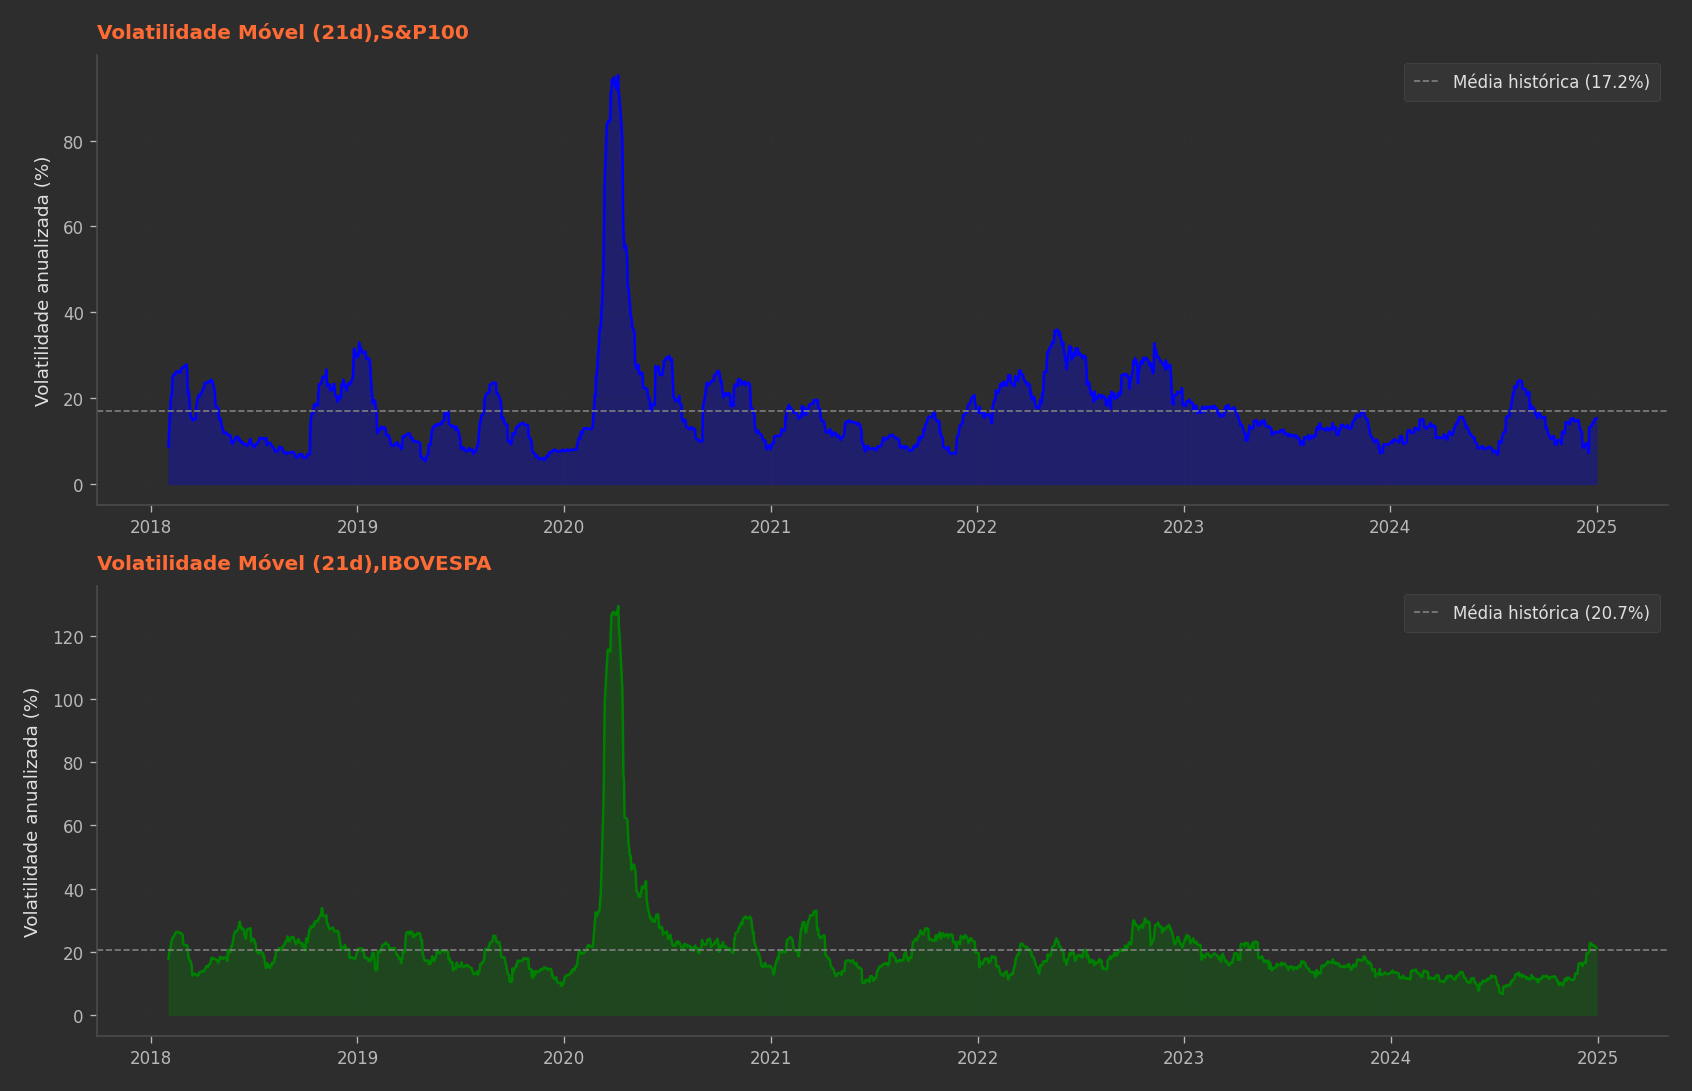

Volatilidade média histórica S&P100: 17.2% a.a.
Volatilidade máxima S&P100: 95.2% a.a.
Data do pico de volatilidade: 2020-04-06

Volatilidade média histórica IBOV: 20.7% a.a.
Volatilidade máxima IBOV: 129.3% a.a.
Data do pico de volatilidade: 2020-04-06


In [ ]:
# Volatilidade móvel (rolling),janela de 21 dias úteis (~1 mês)
vol_sp = ret_idx_sp.rolling(window=21).std() * np.sqrt(252) * 100 # anualizada
vol_ib = ret_idx_ib.rolling(window=21).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

for ax, vol, ret, titulo, cor in [
  (axes[0], vol_sp, ret_idx_sp, 'Volatilidade Móvel (21d),S&P100', 'blue'),
  (axes[1], vol_ib, ret_idx_ib, 'Volatilidade Móvel (21d),IBOVESPA', 'green'),
]:
  ax.fill_between(vol.index, vol.squeeze(), alpha=0.3, color=cor)
  ax.plot(vol.index, vol.squeeze(), color=cor, linewidth=1.5)
  ax.axhline(vol.mean().iloc[0], color='gray', linestyle='--', linewidth=1,
      label=f'Média histórica ({vol.mean().iloc[0]:.1f}%)')
  ax.set_title(titulo, fontweight='bold', fontsize=12)
  ax.set_ylabel('Volatilidade anualizada (%)')
  ax.legend(fontsize=10)
  ax.grid(True, alpha=0.2)

# Marcar COVID
covid_date = '2020-03-01'
# Check if the date exists in the index of the last 'vol' used in the loop (vol_ib in this case)
# For more robustness, check against the full time range or a specific vol.
# However, since the error occurred within the loop's plotting, this part of the fix should be outside the loop
# or the condition should be more specific if both plots need separate covid annotations.
# Given the current context, assuming 'vol' refers to the last iterated vol_ib.
# If sharex=False, each axis could have a different x-range, but the dates are common.
if pd.Timestamp(covid_date) in vol.index:
  ax.axvline(pd.Timestamp(covid_date), color='red',
    linestyle=':', linewidth=2, alpha=0.7, label='COVID-19')

plt.tight_layout()
plt.savefig('volatilidade_movel.png', dpi=150)
plt.show()

# Estatísticas de volatilidade
print(f'Volatilidade média histórica S&P100: {vol_sp.mean().iloc[0]:.1f}% a.a.')
print(f'Volatilidade máxima S&P100: {vol_sp.max().iloc[0]:.1f}% a.a.')
print(f'Data do pico de volatilidade: {vol_sp.idxmax().iloc[0].date()}')
print(f'\nVolatilidade média histórica IBOV: {vol_ib.mean().iloc[0]:.1f}% a.a.')
print(f'Volatilidade máxima IBOV: {vol_ib.max().iloc[0]:.1f}% a.a.')
print(f'Data do pico de volatilidade: {vol_ib.idxmax().iloc[0].date()}')

######3.4.2 Comparativo S&P100 vs. IBOVESPA



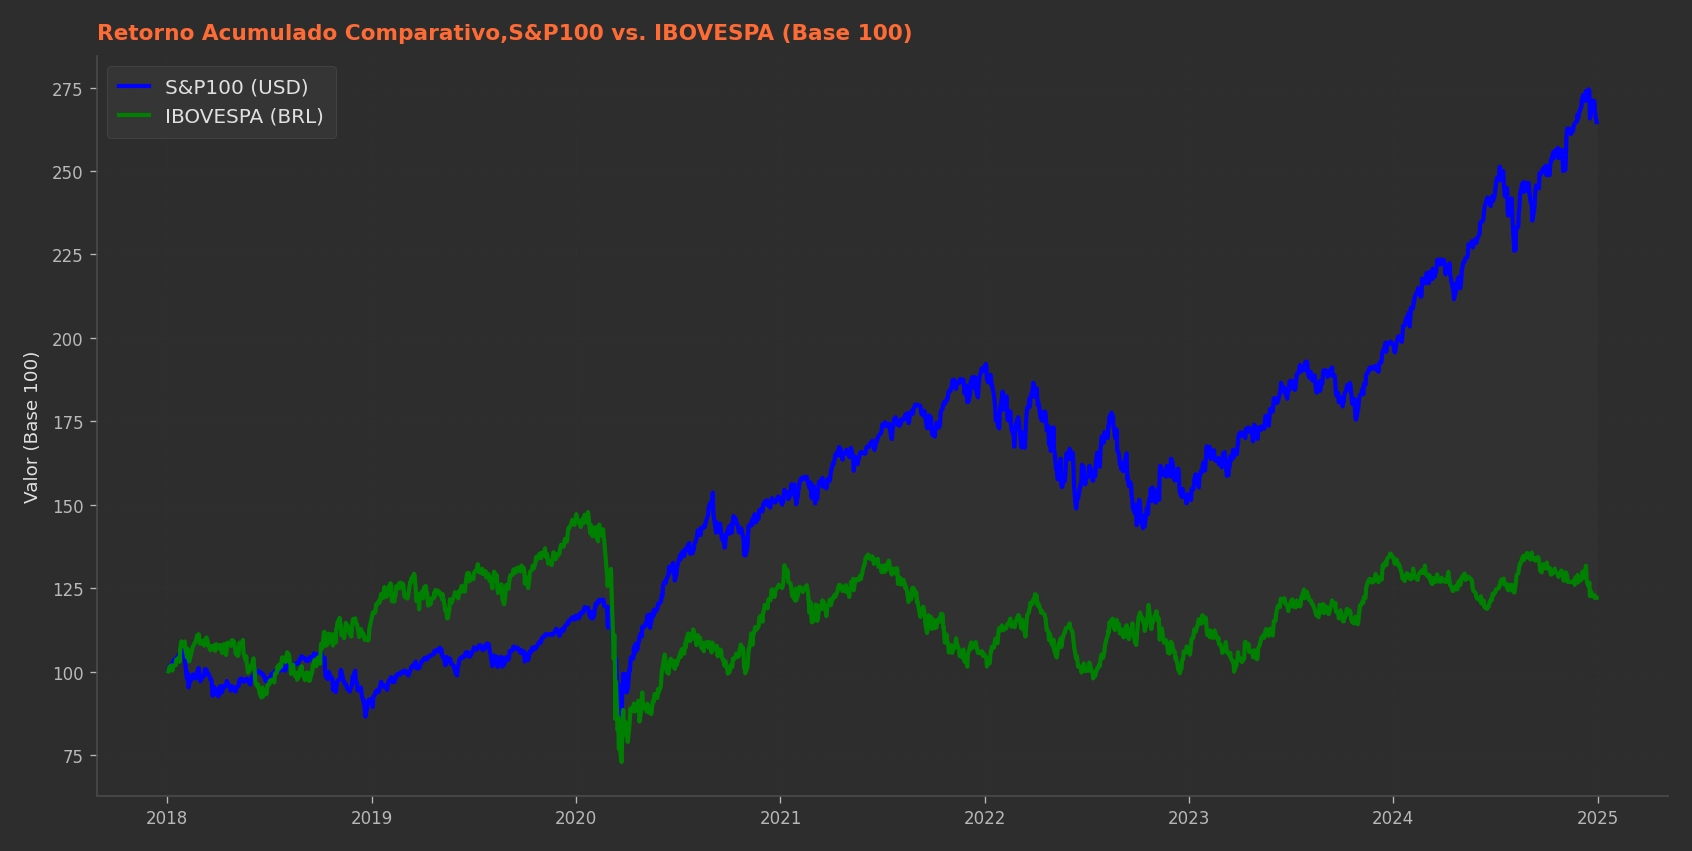


=== COMPARATIVO S&P100 vs. IBOVESPA ===
                          S&P100 IBOVESPA
Retorno anualizado        16.52%    6.06%
Volatilidade anualizada   20.02%   24.61%
Sharpe aproximado          0.825    0.246
Retorno acumulado total   164.6%    22.2%
Pior dia                 -12.29%  -15.99%
Melhor dia                 9.65%   13.02%


In [ ]:
# Alinhar datas dos dois índices para comparação direta
datas_comuns_idx = ret_idx_sp.index.intersection(ret_idx_ib.index)
sp_al = ret_idx_sp.loc[datas_comuns_idx]
ib_al = ret_idx_ib.loc[datas_comuns_idx]

# Retorno acumulado comparativo
sp_acum = (1 + sp_al).cumprod() * 100
ib_acum = (1 + ib_al).cumprod() * 100

plt.figure(figsize=(14, 7))
plt.plot(sp_acum.index, sp_acum, color='blue', lw=2.5, label='S&P100 (USD)')
plt.plot(ib_acum.index, ib_acum, color='green', lw=2.5, label='IBOVESPA (BRL)')
plt.fill_between(sp_acum.index, sp_acum.squeeze(), ib_acum.squeeze(), alpha=0.05, color='gray')
plt.title('Retorno Acumulado Comparativo,S&P100 vs. IBOVESPA (Base 100)',
    fontweight='bold', fontsize=13)
plt.ylabel('Valor (Base 100)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('comparativo_sp100_ibov.png', dpi=150)
plt.show()

# Tabela resumo comparativa
resumo = pd.DataFrame({
  'S&P100': [
    f'{sp_al.mean().iloc[0]*252*100:.2f}%',
    f'{sp_al.std().iloc[0]*np.sqrt(252)*100:.2f}%',
    f'{(sp_al.mean().iloc[0]/sp_al.std().iloc[0]*np.sqrt(252)):.3f}',
    f'{sp_acum.iloc[-1].iloc[0]-100:.1f}%',
    f'{sp_al.min().iloc[0]*100:.2f}%',
    f'{sp_al.max().iloc[0]*100:.2f}%',
  ],
  'IBOVESPA': [
    f'{ib_al.mean().iloc[0]*252*100:.2f}%',
    f'{ib_al.std().iloc[0]*np.sqrt(252)*100:.2f}%',
    f'{(ib_al.mean().iloc[0]/ib_al.std().iloc[0]*np.sqrt(252)):.3f}',
    f'{ib_acum.iloc[-1].iloc[0]-100:.1f}%',
    f'{ib_al.min().iloc[0]*100:.2f}%',
    f'{ib_al.max().iloc[0]*100:.2f}%',
  ]
}, index=['Retorno anualizado', 'Volatilidade anualizada', 'Sharpe aproximado',
  'Retorno acumulado total', 'Pior dia', 'Melhor dia'])

print('\n=== COMPARATIVO S&P100 vs. IBOVESPA ===')
print(resumo.to_string())